## Finding puck boresight

### PLot ECCR trajectory

Loaded SBET: /media/b085164/Elements/ECCR/ODyN/base/reference.out
Records: 1,278,857
Time range: [313393.0000, 319483.8000]


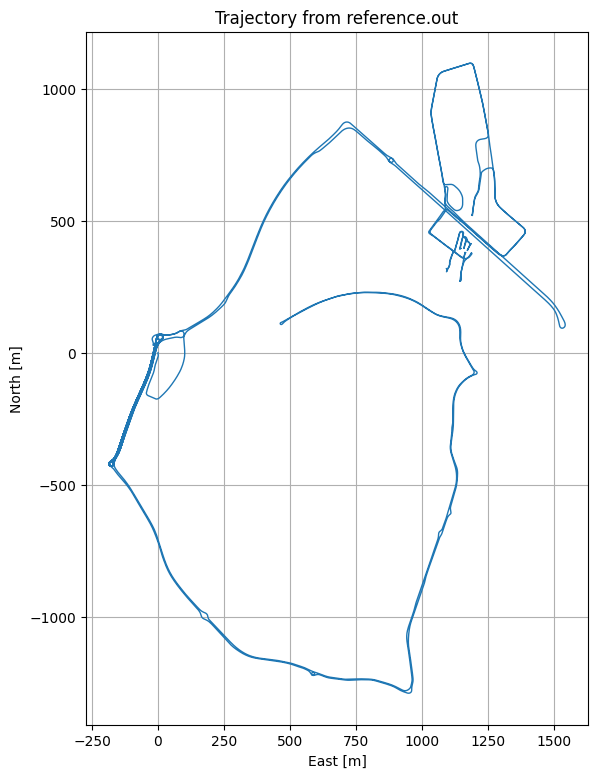

In [2]:
# ============================================================
# Load ONE SBET and plot an interactive single trajectory
# - autonomous cell
# - click on trajectory -> shows GPS time
# - zoom / pan enabled
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
sbet_path = Path("/media/b085164/Elements/ECCR/ODyN/base/reference.out")

# Optional time window
t_start = None   # e.g. 305300.0
t_end   = None   # e.g. 305500.0

# Optional decimation for display
max_display_points = 50000

# ------------------------------------------------------------
# Standard Applanix SBET dtype (17 float64 values per record)
# ------------------------------------------------------------
SBET_DTYPE = np.dtype([
    ("time",        np.float64),
    ("lat",         np.float64),
    ("lon",         np.float64),
    ("alt",         np.float64),
    ("vx",          np.float64),
    ("vy",          np.float64),
    ("vz",          np.float64),
    ("roll",        np.float64),
    ("pitch",       np.float64),
    ("heading",     np.float64),
    ("wander",      np.float64),
    ("ax",          np.float64),
    ("ay",          np.float64),
    ("az",          np.float64),
    ("wx",          np.float64),
    ("wy",          np.float64),
    ("wz",          np.float64),
])

def load_sbet(path: Path) -> pd.DataFrame:
    arr = np.fromfile(path, dtype=SBET_DTYPE)
    if arr.size == 0:
        raise ValueError(f"Empty or unreadable SBET file: {path}")
    return pd.DataFrame(arr)

def geodetic_to_local_enu(lat, lon, h, lat0, lon0, h0):
    a = 6378137.0
    f = 1 / 298.257223563
    e2 = f * (2 - f)

    def geodetic_to_ecef(lat, lon, h):
        sin_lat = np.sin(lat)
        cos_lat = np.cos(lat)
        sin_lon = np.sin(lon)
        cos_lon = np.cos(lon)
        N = a / np.sqrt(1 - e2 * sin_lat**2)
        X = (N + h) * cos_lat * cos_lon
        Y = (N + h) * cos_lat * sin_lon
        Z = (N * (1 - e2) + h) * sin_lat
        return X, Y, Z

    X, Y, Z = geodetic_to_ecef(lat, lon, h)
    X0, Y0, Z0 = geodetic_to_ecef(lat0, lon0, h0)

    dX = X - X0
    dY = Y - Y0
    dZ = Z - Z0

    sin_lat0 = np.sin(lat0)
    cos_lat0 = np.cos(lat0)
    sin_lon0 = np.sin(lon0)
    cos_lon0 = np.cos(lon0)

    R = np.array([
        [-sin_lon0,              cos_lon0,             0],
        [-sin_lat0*cos_lon0, -sin_lat0*sin_lon0, cos_lat0],
        [ cos_lat0*cos_lon0,  cos_lat0*sin_lon0, sin_lat0],
    ])

    xyz = np.vstack([dX, dY, dZ])
    enu = R @ xyz
    return enu[0], enu[1], enu[2]

# ------------------------------------------------------------
# Load and filter
# ------------------------------------------------------------
df = load_sbet(sbet_path)

print(f"Loaded SBET: {sbet_path}")
print(f"Records: {len(df):,}")
print(f"Time range: [{df.time.min():.4f}, {df.time.max():.4f}]")

mask = np.ones(len(df), dtype=bool)
if t_start is not None:
    mask &= df.time.to_numpy() >= t_start
if t_end is not None:
    mask &= df.time.to_numpy() <= t_end

dfw = df.loc[mask].copy()
if len(dfw) == 0:
    raise ValueError("No samples in selected time window.")

lat = dfw.lat.to_numpy()
lon = dfw.lon.to_numpy()
alt = dfw.alt.to_numpy()
time_gps = dfw.time.to_numpy()

lat0, lon0, h0 = lat[0], lon[0], alt[0]
E, N, U = geodetic_to_local_enu(lat, lon, alt, lat0, lon0, h0)

# Optional decimation
n = len(time_gps)
if n > max_display_points:
    idx = np.linspace(0, n - 1, max_display_points).astype(int)
    E = E[idx]
    N = N[idx]
    time_gps = time_gps[idx]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 9))
ax.plot(E, N, '-', lw=1)
ax.set_title(f"Trajectory from {sbet_path.name}")
ax.set_xlabel("East [m]")
ax.set_ylabel("North [m]")
ax.set_aspect('equal', adjustable='box')
ax.grid(True)

selected_pt, = ax.plot([], [], 'rx', ms=10, mew=2)
annotation = ax.annotate(
    "",
    xy=(0, 0),
    xytext=(10, 10),
    textcoords="offset points",
    bbox=dict(boxstyle="round", fc="white", alpha=0.8),
)
annotation.set_visible(False)

def on_click(event):
    if event.inaxes != ax or event.xdata is None or event.ydata is None:
        return

    dx = E - event.xdata
    dy = N - event.ydata
    i = np.argmin(dx * dx + dy * dy)

    e_sel = E[i]
    n_sel = N[i]
    t_sel = time_gps[i]

    selected_pt.set_data([e_sel], [n_sel])
    annotation.xy = (e_sel, n_sel)
    annotation.set_text(
        f"GPS time: {t_sel:.4f}\n"
        f"E: {e_sel:.3f} m\n"
        f"N: {n_sel:.3f} m\n"
        f"idx: {i}"
    )
    annotation.set_visible(True)

    print(f"Selected point -> GPS time: {t_sel:.4f} | E={e_sel:.3f} m | N={n_sel:.3f} m")
    fig.canvas.draw_idle()

cid = fig.canvas.mpl_connect("button_press_event", on_click)
plt.show()

### Extract subclouds

In [25]:
from pathlib import Path
from collections import defaultdict
import numpy as np
import laspy

# ============================================================
# GLOBAL ASCII OPTIONS
# ============================================================
delimiter = ","
skiprows = 0
time_col = 0

# ============================================================
# JOB LIST
# ============================================================
jobs = [
    {
        "input_cloud": Path("/media/b085164/Elements/CALIB_26_02_25/georef_puck/test_puck/PUCK/lidar_20260225_124315_pcd.las"),
        "start": 305080.0,
        "end": 305090.0,
        "output_cloud": Path("/media/b085164/Elements/CALIB_26_02_25/georef_puck/PUCK/calib/output_cloud_1.las"),
    },
    {
        "input_cloud": Path("/media/b085164/Elements/CALIB_26_02_25/georef_VUX/merged/HA_LR/merged_1000_HA_LR.las"),
        "start": 305080.0,
        "end": 305090.0,
        "output_cloud": Path("/media/b085164/Elements/CALIB_26_02_25/georef_puck/PUCK/calib/output_cloud_2.las"),
    },
    
]

# ============================================================
# HELPERS
# ============================================================
def extract_many_las_by_time(infile: Path, file_jobs: list[dict]):
    las = laspy.read(infile)

    if "gps_time" not in las.point_format.dimension_names:
        raise ValueError(f"No gps_time found in LAS file: {infile}")

    gps_time = np.asarray(las.gps_time)
    n_total = len(gps_time)

    print(f"\n[LAS] Loaded once: {infile}")
    print(f"      total points: {n_total}")

    for job in file_jobs:
        t0 = float(job["start"])
        t1 = float(job["end"])
        outfile = Path(job["output_cloud"])

        mask = (gps_time >= t0) & (gps_time <= t1)
        n_kept = int(mask.sum())

        if n_kept == 0:
            print(f"[WARN] No LAS points found in [{t0}, {t1}] for {infile.name}")
            continue

        sub = laspy.LasData(las.header)
        sub.points = las.points[mask]

        outfile.parent.mkdir(parents=True, exist_ok=True)
        sub.write(outfile)

        print(f"[LAS] {outfile}")
        print(f"      kept {n_kept}/{n_total} points in [{t0}, {t1}]")

def extract_many_ascii_by_time(
    infile: Path,
    file_jobs: list[dict],
    delimiter=",",
    skiprows=0,
    time_col=0,
):
    arr = np.loadtxt(infile, delimiter=delimiter, skiprows=skiprows)

    if arr.ndim == 1:
        arr = arr.reshape(1, -1)

    time = arr[:, time_col]
    n_total = len(time)

    print(f"\n[ASCII] Loaded once: {infile}")
    print(f"        total rows: {n_total}")

    for job in file_jobs:
        t0 = float(job["start"])
        t1 = float(job["end"])
        outfile = Path(job["output_cloud"])

        mask = (time >= t0) & (time <= t1)
        n_kept = int(mask.sum())

        if n_kept == 0:
            print(f"[WARN] No ASCII rows found in [{t0}, {t1}] for {infile.name}")
            continue

        sub = arr[mask]

        outfile.parent.mkdir(parents=True, exist_ok=True)
        np.savetxt(outfile, sub, delimiter=delimiter, fmt="%.10f")

        print(f"[ASCII] {outfile}")
        print(f"        kept {n_kept}/{n_total} rows in [{t0}, {t1}]")

# ============================================================
# GROUP JOBS BY INPUT FILE
# ============================================================
jobs_by_input = defaultdict(list)
for job in jobs:
    jobs_by_input[Path(job["input_cloud"])].append(job)

# ============================================================
# RUN
# ============================================================
for i, (infile, file_jobs) in enumerate(jobs_by_input.items(), start=1):
    print("\n" + "=" * 60)
    print(f"INPUT FILE {i}/{len(jobs_by_input)}")
    print("=" * 60)

    if not infile.exists():
        print(f"[ERROR] Input file does not exist: {infile}")
        continue

    suffix = infile.suffix.lower()

    if suffix in [".las", ".laz"]:
        extract_many_las_by_time(infile, file_jobs)

    elif suffix in [".txt", ".csv", ".asc"]:
        extract_many_ascii_by_time(
            infile,
            file_jobs,
            delimiter=delimiter,
            skiprows=skiprows,
            time_col=time_col,
        )
    else:
        raise ValueError(f"Unsupported input format: {suffix}")


INPUT FILE 1/2

[LAS] Loaded once: /media/b085164/Elements/CALIB_26_02_25/georef_puck/test_puck/PUCK/lidar_20260225_124315_pcd.las
      total points: 45459189
[LAS] /media/b085164/Elements/CALIB_26_02_25/georef_puck/PUCK/calib/output_cloud_1.las
      kept 1117804/45459189 points in [305080.0, 305090.0]

INPUT FILE 2/2

[LAS] Loaded once: /media/b085164/Elements/CALIB_26_02_25/georef_VUX/merged/HA_LR/merged_1000_HA_LR.las
      total points: 319116685
[LAS] /media/b085164/Elements/CALIB_26_02_25/georef_puck/PUCK/calib/output_cloud_2.las
      kept 9376366/319116685 points in [305080.0, 305090.0]


## Crop nuage 

In [4]:
from pathlib import Path
import numpy as np
import laspy
from matplotlib.path import Path as MplPath

# ============================================================
# INPUT / OUTPUT JOBS
# ============================================================
jobs = [
    {
        "input_cloud": Path("/media/b085164/Elements/CALIB_26_02_25/crops/georef_puck/PUCK/lidar_20260225_124315_pcd.las"),
        "output_cloud": Path("/media/b085164/Elements/CALIB_26_02_25/crops/v2/cloud_1.las"),
    },
    {
        "input_cloud": Path("/media/b085164/Elements/CALIB_26_02_25/crops/georef_puck/PUCK/lidar_20260225_125030_pcd.las"),
        "output_cloud": Path("/media/b085164/Elements/CALIB_26_02_25/crops/v2/cloud_2.las"),
    },
]

# ============================================================
# RECTANGLE CORNERS (global coords Xg, Yg)
# ============================================================
corners = np.array([
    [2542337.899994, 1157075.195007],
    [2542354.688995, 1157096.387024],
    [2542392.407013, 1157065.625977],
    [2542375.092987, 1157043.383972],
], dtype=np.float64)

# ============================================================
# PARAMETERS
# ============================================================
time_gap_threshold = 0.5  # seconds

# ============================================================
# HELPERS
# ============================================================
def order_polygon_points(pts):
    c = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0])
    return pts[np.argsort(ang)]

def crop_first_passage_las(input_cloud: Path, output_cloud: Path, polygon_xy: np.ndarray, time_gap_threshold: float = 0.5):
    las = laspy.read(input_cloud)

    if "gps_time" not in las.point_format.dimension_names:
        raise ValueError(f"'gps_time' not found in {input_cloud}")

    x = np.asarray(las.x)
    y = np.asarray(las.y)
    gps_time = np.asarray(las.gps_time)

    poly = order_polygon_points(polygon_xy)
    poly_path = MplPath(poly)

    xy = np.column_stack((x, y))
    mask_spatial = poly_path.contains_points(xy)

    n_spatial = int(mask_spatial.sum())
    print(f"\n[INPUT] {input_cloud.name}")
    print(f"Total points: {len(las.points)}")
    print(f"Points inside rectangle: {n_spatial}")

    if n_spatial == 0:
        print("[WARN] No points found inside rectangle.")
        return

    idx_spatial = np.where(mask_spatial)[0]
    t_spatial = gps_time[idx_spatial]

    order = np.argsort(t_spatial)
    idx_sorted = idx_spatial[order]
    t_sorted = t_spatial[order]

    dt = np.diff(t_sorted)
    breaks = np.where(dt > time_gap_threshold)[0]

    if len(breaks) == 0:
        idx_first_pass = idx_sorted
    else:
        idx_first_pass = idx_sorted[:breaks[0] + 1]

    n_first = len(idx_first_pass)
    t0 = float(gps_time[idx_first_pass].min())
    t1 = float(gps_time[idx_first_pass].max())

    sub = laspy.LasData(las.header)
    sub.points = las.points[idx_first_pass]

    output_cloud.parent.mkdir(parents=True, exist_ok=True)
    sub.write(output_cloud)

    print(f"First passage kept: {n_first} points")
    print(f"Time range: [{t0:.6f}, {t1:.6f}]")
    print(f"Saved: {output_cloud}")

# ============================================================
# RUN
# ============================================================
for job in jobs:
    crop_first_passage_las(
        input_cloud=job["input_cloud"],
        output_cloud=job["output_cloud"],
        polygon_xy=corners,
        time_gap_threshold=time_gap_threshold,
    )


[INPUT] lidar_20260225_124315_pcd.las
Total points: 45459189
Points inside rectangle: 244776
First passage kept: 244776 points
Time range: [305085.633392, 305090.983550]
Saved: /media/b085164/Elements/CALIB_26_02_25/crops/v2/cloud_1.las

[INPUT] lidar_20260225_125030_pcd.las
Total points: 161935392
Points inside rectangle: 638261
First passage kept: 199949 points
Time range: [305981.530989, 305986.594932]
Saved: /media/b085164/Elements/CALIB_26_02_25/crops/v2/cloud_2.las


In [4]:
# ============================================================
# Compare TWO binary SBET .out trajectories in one interactive plot
# - autonomous cell
# - Plotly interactive: zoom / pan / hover / legend toggle
# - common local ENU frame
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
out2_path = Path("/media/b085164/Elements/ECCR/ODyN/Zone_1/outage/out/outage_zone_1.out") #JV
out3_path = Path("/media/b085164/Elements/ECCR/ODyN/base/out/ODyN_GNSS_INS.out") # ODyN

label2 = "outage"
label3 = "sbet ODyN"


# Optional time window
t_start = None   # e.g. 466930.0
t_end   = None   # e.g. 466980.0

# Optional decimation for display
max_display_points = 50000

# ------------------------------------------------------------
# Standard Applanix SBET dtype (17 float64 values per record)
# ------------------------------------------------------------
SBET_DTYPE = np.dtype([
    ("time",        np.float64),
    ("lat",         np.float64),
    ("lon",         np.float64),
    ("alt",         np.float64),
    ("vx",          np.float64),
    ("vy",          np.float64),
    ("vz",          np.float64),
    ("roll",        np.float64),
    ("pitch",       np.float64),
    ("heading",     np.float64),
    ("wander",      np.float64),
    ("ax",          np.float64),
    ("ay",          np.float64),
    ("az",          np.float64),
    ("wx",          np.float64),
    ("wy",          np.float64),
    ("wz",          np.float64),
])

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def load_sbet(path: Path) -> pd.DataFrame:
    arr = np.fromfile(path, dtype=SBET_DTYPE)
    if arr.size == 0:
        raise ValueError(f"Empty or unreadable SBET file: {path}")
    return pd.DataFrame(arr)

def geodetic_to_local_enu(lat, lon, h, lat0, lon0, h0):
    a = 6378137.0
    f = 1 / 298.257223563
    e2 = f * (2 - f)

    def geodetic_to_ecef(lat, lon, h):
        sin_lat = np.sin(lat)
        cos_lat = np.cos(lat)
        sin_lon = np.sin(lon)
        cos_lon = np.cos(lon)
        N = a / np.sqrt(1 - e2 * sin_lat**2)
        X = (N + h) * cos_lat * cos_lon
        Y = (N + h) * cos_lat * sin_lon
        Z = (N * (1 - e2) + h) * sin_lat
        return X, Y, Z

    X, Y, Z = geodetic_to_ecef(lat, lon, h)
    X0, Y0, Z0 = geodetic_to_ecef(lat0, lon0, h0)

    dX = X - X0
    dY = Y - Y0
    dZ = Z - Z0

    sin_lat0 = np.sin(lat0)
    cos_lat0 = np.cos(lat0)
    sin_lon0 = np.sin(lon0)
    cos_lon0 = np.cos(lon0)

    R = np.array([
        [-sin_lon0,               cos_lon0,              0],
        [-sin_lat0 * cos_lon0, -sin_lat0 * sin_lon0,  cos_lat0],
        [ cos_lat0 * cos_lon0,  cos_lat0 * sin_lon0,  sin_lat0],
    ])

    xyz = np.vstack([dX, dY, dZ])
    enu = R @ xyz
    return enu[0], enu[1], enu[2]

def filter_time_window(df, t_start=None, t_end=None):
    mask = np.ones(len(df), dtype=bool)
    if t_start is not None:
        mask &= df["time"].to_numpy() >= t_start
    if t_end is not None:
        mask &= df["time"].to_numpy() <= t_end
    out = df.loc[mask].copy()
    if len(out) == 0:
        raise ValueError("No samples in selected time window.")
    return out

def decimate_indices(n, max_points):
    if n <= max_points:
        return np.arange(n)
    return np.linspace(0, n - 1, max_points).astype(int)

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
df2 = load_sbet(out2_path)
df3 = load_sbet(out3_path)

print(f"Loaded 2: {out2_path}")
print(f"  records: {len(df2):,}")
print(f"  time range: [{df2.time.min():.4f}, {df2.time.max():.4f}]")

print(f"Loaded 3: {out3_path}")
print(f"  records: {len(df3):,}")
print(f"  time range: [{df3.time.min():.4f}, {df3.time.max():.4f}]")

# ------------------------------------------------------------
# Filter time window
# ------------------------------------------------------------
df2 = filter_time_window(df2, t_start, t_end)
df3 = filter_time_window(df3, t_start, t_end)

# ------------------------------------------------------------
# Common ENU origin
# Use first point of trajectory 1 as reference
# ------------------------------------------------------------
lat0 = df2["lat"].iloc[0]
lon0 = df2["lon"].iloc[0]
h0   = df2["alt"].iloc[0]


E2, N2, U2 = geodetic_to_local_enu(
    df2["lat"].to_numpy(),
    df2["lon"].to_numpy(),
    df2["alt"].to_numpy(),
    lat0, lon0, h0
)

E3, N3, U3 = geodetic_to_local_enu(
    df3["lat"].to_numpy(),
    df3["lon"].to_numpy(),
    df3["alt"].to_numpy(),
    lat0, lon0, h0
)


t2 = df2["time"].to_numpy()
t3 = df3["time"].to_numpy()

# ------------------------------------------------------------
# Optional decimation
# ------------------------------------------------------------
idx2 = decimate_indices(len(t2), max_display_points)
idx3 = decimate_indices(len(t3), max_display_points)


E2, N2, U2, t2 = E2[idx2], N2[idx2], U2[idx2], t2[idx2]
E3, N3, U3, t3 = E3[idx3], N3[idx3], U3[idx3], t3[idx3]


# ------------------------------------------------------------
# Interactive plot
# ------------------------------------------------------------
fig = go.Figure()

fig.add_trace(go.Scattergl(
    x=E2,
    y=N2,
    mode="lines",
    name=label2,
    customdata=np.column_stack([t2, U2]),
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "GPS time: %{customdata[0]:.4f}<br>"
        "East: %{x:.3f} m<br>"
        "North: %{y:.3f} m<br>"
        "Up: %{customdata[1]:.3f} m"
        "<extra></extra>"
    )
))

fig.add_trace(go.Scattergl(
    x=E3,
    y=N3,
    mode="lines",
    name=label3,
    customdata=np.column_stack([t3, U3]),
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "GPS time: %{customdata[0]:.4f}<br>"
        "East: %{x:.3f} m<br>"
        "North: %{y:.3f} m<br>"
        "Up: %{customdata[1]:.3f} m"
        "<extra></extra>"
    )
))

fig.update_layout(
    title="Comparison of three SBET trajectories",
    xaxis_title="East [m]",
    yaxis_title="North [m]",
    template="plotly_white",
    height=850,
    width=950,
    hovermode="closest",
    legend=dict(
        x=0.01,
        y=0.99,
        bgcolor="rgba(255,255,255,0.8)"
    )
)

fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1
)

fig.show()

FileNotFoundError: [Errno 2] No such file or directory: '/media/b085164/Elements/ECCR/ODyN/Zone_1/outage/out/outage_zone_1.out'

# plot traj calib

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import folium

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
out2_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/base_v0/out/ODyN_GNSS_INS.out")
out3_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/Outage_2_305645_306120/traj_outage/outage_2.out")
out4_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/Outage_2_305645_306120/F2B/out/v2/traj_F2B_2.out")

label2 = "ODyN"
label3 = "ODyN outage"
label4 = "F2B"
t_start = None
t_end   = None
max_display_points = 5000
output_html = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_outage_2_airins.html")

# ------------------------------------------------------------
# SBET dtype + helpers
# ------------------------------------------------------------
SBET_DTYPE = np.dtype([
    ("time",    np.float64), ("lat",  np.float64), ("lon",   np.float64),
    ("alt",     np.float64), ("vx",   np.float64), ("vy",    np.float64),
    ("vz",      np.float64), ("roll", np.float64), ("pitch", np.float64),
    ("heading", np.float64), ("wander",np.float64),("ax",    np.float64),
    ("ay",      np.float64), ("az",   np.float64), ("wx",    np.float64),
    ("wy",      np.float64), ("wz",   np.float64),
])

def load_sbet(path):
    return pd.DataFrame(np.fromfile(path, dtype=SBET_DTYPE))

def filter_time_window(df, t0, t1):
    mask = np.ones(len(df), dtype=bool)
    if t0 is not None: mask &= df["time"].to_numpy() >= t0
    if t1 is not None: mask &= df["time"].to_numpy() <= t1
    out = df.loc[mask].copy()
    if len(out) == 0:
        raise ValueError("No samples in selected time window.")
    return out

def decimate(arr, n):
    if len(arr) <= n: return arr
    return arr[np.linspace(0, len(arr)-1, n).astype(int)]

# ------------------------------------------------------------
# Load + filter
# ------------------------------------------------------------
df2 = filter_time_window(load_sbet(out2_path), t_start, t_end)
df3 = filter_time_window(load_sbet(out3_path), t_start, t_end)
df4 = filter_time_window(load_sbet(out4_path), t_start, t_end)

lat2 = np.degrees(decimate(df2["lat"].to_numpy(), max_display_points))
lon2 = np.degrees(decimate(df2["lon"].to_numpy(), max_display_points))
lat3 = np.degrees(decimate(df3["lat"].to_numpy(), max_display_points))
lon3 = np.degrees(decimate(df3["lon"].to_numpy(), max_display_points))
lat4 = np.degrees(decimate(df4["lat"].to_numpy(), max_display_points))
lon4 = np.degrees(decimate(df4["lon"].to_numpy(), max_display_points))

# ------------------------------------------------------------
# Folium map
# ------------------------------------------------------------
center = [lat2.mean(), lon2.mean()]
m = folium.Map(location=center, zoom_start=14, tiles="CartoDB positron")

folium.PolyLine(
    locations=list(zip(lat2, lon2)),
    color="#e74c3c", weight=2, opacity=0.9,
    tooltip=label2,
).add_to(m)
folium.PolyLine(
    locations=list(zip(lat3, lon3)),
    color="#2980b9", weight=2, opacity=0.9,
    tooltip=label3,
).add_to(m)
folium.PolyLine(
    locations=list(zip(lat4, lon4)),
    color="#27ae60", weight=2, opacity=0.9,
    tooltip=label4,
).add_to(m)

legend_html = f"""
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
            background:white;padding:8px 12px;border-radius:6px;
            box-shadow:2px 2px 6px rgba(0,0,0,0.3);font-size:13px;">
  <span style="color:#e74c3c;">&#9644;</span> {label2}<br>
  <span style="color:#2980b9;">&#9644;</span> {label3}<br>
  <span style="color:#27ae60;">&#9644;</span> {label4}
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
m.save(str(output_html))
print(f"Saved: {output_html}")

Saved: /home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_outage_2_airins.html


# TRAJ CALIB OUTAGE 1

In [56]:
from pathlib import Path
import numpy as np
import pandas as pd
import folium

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
out2_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/base/out/ODyN_CALIB.out")
out3_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_1/OUTAGE/out/outage_1_APX.out")
out4_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_1/F2B/out/F2B_out1_apx.out")
out5_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_1/COMBINED/out/COMBINED_out1_apx.out")

label2 = "AIRINS Reference"
label3 = "APX15 outage"
label4 = "APX15 F2B"
label5 = "APX15 Combined"

t_start = None
t_end   = None
max_display_points = 5000
output_html = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_outage_1_apx.html")

# ------------------------------------------------------------
# SBET dtype + helpers
# ------------------------------------------------------------
SBET_DTYPE = np.dtype([
    ("time",    np.float64), ("lat",  np.float64), ("lon",   np.float64),
    ("alt",     np.float64), ("vx",   np.float64), ("vy",    np.float64),
    ("vz",      np.float64), ("roll", np.float64), ("pitch", np.float64),
    ("heading", np.float64), ("wander",np.float64),("ax",    np.float64),
    ("ay",      np.float64), ("az",   np.float64), ("wx",    np.float64),
    ("wy",      np.float64), ("wz",   np.float64),
])

def load_sbet(path):
    return pd.DataFrame(np.fromfile(path, dtype=SBET_DTYPE))

def filter_time_window(df, t0, t1):
    mask = np.ones(len(df), dtype=bool)
    if t0 is not None: mask &= df["time"].to_numpy() >= t0
    if t1 is not None: mask &= df["time"].to_numpy() <= t1
    out = df.loc[mask].copy()
    if len(out) == 0:
        raise ValueError("No samples in selected time window.")
    return out

def decimate(arr, n):
    if len(arr) <= n: return arr
    return arr[np.linspace(0, len(arr)-1, n).astype(int)]
def decimate_times(df, n):
    arr = df["time"].to_numpy()
    if len(arr) <= n: return arr
    return arr[np.linspace(0, len(arr)-1, n).astype(int)]

def add_traj_with_time(m, lats, lons, times, color, label, group):
    for i in range(len(lats) - 1):
        folium.PolyLine(
            locations=[(lats[i], lons[i]), (lats[i+1], lons[i+1])],
            color=color, weight=2, opacity=0.9,
            tooltip=f"{label} | t = {times[i]:.3f} s",
        ).add_to(group)
# ------------------------------------------------------------
# Load + filter
# ------------------------------------------------------------
df2 = filter_time_window(load_sbet(out2_path), t_start, t_end)
df3 = filter_time_window(load_sbet(out3_path), t_start, t_end)
df4 = filter_time_window(load_sbet(out4_path), t_start, t_end)
df5 = filter_time_window(load_sbet(out5_path), t_start, t_end)

lat2 = np.degrees(decimate(df2["lat"].to_numpy(), max_display_points))
lon2 = np.degrees(decimate(df2["lon"].to_numpy(), max_display_points))
lat3 = np.degrees(decimate(df3["lat"].to_numpy(), max_display_points))
lon3 = np.degrees(decimate(df3["lon"].to_numpy(), max_display_points))
lat4 = np.degrees(decimate(df4["lat"].to_numpy(), max_display_points))
lon4 = np.degrees(decimate(df4["lon"].to_numpy(), max_display_points))
lat5 = np.degrees(decimate(df5["lat"].to_numpy(), max_display_points))
lon5 = np.degrees(decimate(df5["lon"].to_numpy(), max_display_points))
# ------------------------------------------------------------
# Folium map
# ------------------------------------------------------------
center = [lat2.mean(), lon2.mean()]
m = folium.Map(location=center, zoom_start=14,
               max_zoom=22,
               tiles="https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
               attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/">CARTO</a>')

t2 = decimate_times(df2, max_display_points)
t3 = decimate_times(df3, max_display_points)
t4 = decimate_times(df4, max_display_points)
t5 = decimate_times(df5, max_display_points)

fg2 = folium.FeatureGroup(name=label2, show=True).add_to(m)
add_traj_with_time(m, lat2, lon2, t2, "#e74c3c", label2, fg2)

fg3 = folium.FeatureGroup(name=label3, show=True).add_to(m)
add_traj_with_time(m, lat3, lon3, t3, "#2980b9", label3, fg3)

fg4 = folium.FeatureGroup(name=label4, show=True).add_to(m)
add_traj_with_time(m, lat4, lon4, t4, "#27ae60", label4, fg4)

fg5 = folium.FeatureGroup(name=label5, show=True).add_to(m)
add_traj_with_time(m, lat5, lon5, t5, "#e67e22", label5, fg5)

folium.LayerControl(collapsed=False).add_to(m)

legend_html = f"""
<div style="position:fixed;top:30px;right:30px;z-index:1000;
            background:white;padding:8px 12px;border-radius:6px;
            box-shadow:2px 2px 6px rgba(0,0,0,0.3);font-size:13px;">
  <span style="color:#e74c3c;">&#9644;</span> {label2}<br>
  <span style="color:#2980b9;">&#9644;</span> {label3}<br>
  <span style="color:#27ae60;">&#9644;</span> {label4}<br>
  <span style="color:#e67e22;">&#9644;</span> {label5}
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

from folium import plugins
folium.plugins.MeasureControl(position="bottomright", primary_length_unit="meters", max_width=300).add_to(m)
m.get_root().html.add_child(folium.Element("""
<script>
  document.addEventListener("DOMContentLoaded", function() {
    var maps = Object.values(window).filter(v => v && v._leaflet_id);
    if (maps.length) L.control.scale({position:"bottomright", imperial:false, maxWidth:400}).addTo(maps[0]);
  });
</script>
"""))
m.save(str(output_html))
print(f"Saved: {output_html}")

Saved: /home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_outage_1_apx.html


# traj calib outage 3

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import folium
from folium import plugins

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
out2_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/base/out/ODyN_CALIB.out")
out3_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_3/OUTAGE/out/outage_3_apx.out")
out4_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_3/F2B/out/F2B_out3_apx.out")
out5_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_3/COMBINED/out/COMBINED_out3_apx.out")  # <-- À adapter

label2 = "AIRINS Reference"
label3 = "APX15 outage"
label4 = "APX15 F2B"
label5 = "APX15 Combined"  
t_start = None
t_end   = None
max_display_points = 5000
output_html = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_outage_3_apx.html")

# ------------------------------------------------------------
# SBET dtype + helpers
# ------------------------------------------------------------
SBET_DTYPE = np.dtype([
    ("time",    np.float64), ("lat",  np.float64), ("lon",   np.float64),
    ("alt",     np.float64), ("vx",   np.float64), ("vy",    np.float64),
    ("vz",      np.float64), ("roll", np.float64), ("pitch", np.float64),
    ("heading", np.float64), ("wander",np.float64),("ax",    np.float64),
    ("ay",      np.float64), ("az",   np.float64), ("wx",    np.float64),
    ("wy",      np.float64), ("wz",   np.float64),
])

def load_sbet(path):
    return pd.DataFrame(np.fromfile(path, dtype=SBET_DTYPE))

def filter_time_window(df, t0, t1):
    mask = np.ones(len(df), dtype=bool)
    if t0 is not None: mask &= df["time"].to_numpy() >= t0
    if t1 is not None: mask &= df["time"].to_numpy() <= t1
    out = df.loc[mask].copy()
    if len(out) == 0:
        raise ValueError("No samples in selected time window.")
    return out

def decimate(arr, n):
    if len(arr) <= n: return arr
    return arr[np.linspace(0, len(arr)-1, n).astype(int)]

def decimate_times(df, n):
    arr = df["time"].to_numpy()
    if len(arr) <= n: return arr
    return arr[np.linspace(0, len(arr)-1, n).astype(int)]

def add_traj_with_time(m, lats, lons, times, color, label, group):
    for i in range(len(lats) - 1):
        folium.PolyLine(
            locations=[(lats[i], lons[i]), (lats[i+1], lons[i+1])],
            color=color, weight=2, opacity=0.9,
            tooltip=f"{label} | t = {times[i]:.3f} s",
        ).add_to(group)

# ------------------------------------------------------------
# Load + filter
# ------------------------------------------------------------
df2 = filter_time_window(load_sbet(out2_path), t_start, t_end)
df3 = filter_time_window(load_sbet(out3_path), t_start, t_end)
df4 = filter_time_window(load_sbet(out4_path), t_start, t_end)
df5 = filter_time_window(load_sbet(out5_path), t_start, t_end)

lat2 = np.degrees(decimate(df2["lat"].to_numpy(), max_display_points))
lon2 = np.degrees(decimate(df2["lon"].to_numpy(), max_display_points))
lat3 = np.degrees(decimate(df3["lat"].to_numpy(), max_display_points))
lon3 = np.degrees(decimate(df3["lon"].to_numpy(), max_display_points))
lat4 = np.degrees(decimate(df4["lat"].to_numpy(), max_display_points))
lon4 = np.degrees(decimate(df4["lon"].to_numpy(), max_display_points))
lat5 = np.degrees(decimate(df5["lat"].to_numpy(), max_display_points))
lon5 = np.degrees(decimate(df5["lon"].to_numpy(), max_display_points))

# ------------------------------------------------------------
# Folium map
# ------------------------------------------------------------
center = [lat2.mean(), lon2.mean()]
m = folium.Map(location=center, zoom_start=14,
               max_zoom=22,
               tiles="https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
               attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/">CARTO</a>')

t2 = decimate_times(df2, max_display_points)
t3 = decimate_times(df3, max_display_points)
t4 = decimate_times(df4, max_display_points)
t5 = decimate_times(df5, max_display_points)

fg2 = folium.FeatureGroup(name=label2, show=True).add_to(m)
add_traj_with_time(m, lat2, lon2, t2, "#e74c3c", label2, fg2)

fg3 = folium.FeatureGroup(name=label3, show=True).add_to(m)
add_traj_with_time(m, lat3, lon3, t3, "#2980b9", label3, fg3)

fg4 = folium.FeatureGroup(name=label4, show=True).add_to(m)
add_traj_with_time(m, lat4, lon4, t4, "#27ae60", label4, fg4)

fg5 = folium.FeatureGroup(name=label5, show=True).add_to(m)
add_traj_with_time(m, lat5, lon5, t5, "#e67e22", label5, fg5)

folium.LayerControl(collapsed=False).add_to(m)

legend_html = f"""
<div style="
    position: fixed;
    bottom: 30px;
    left: 30px;
    z-index: 1000;
    background: white;
    padding: 8px 12px;
    border-radius: 6px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    font-size: 13px;
">
  <span style="color:#e74c3c;">&#9644;</span> {label2}<br>
  <span style="color:#2980b9;">&#9644;</span> {label3}<br>
  <span style="color:#27ae60;">&#9644;</span> {label4}<br>
  <span style="color:#e67e22;">&#9644;</span> {label5}
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

folium.plugins.MeasureControl(position="bottomright", primary_length_unit="meters", max_width=300).add_to(m)
m.get_root().html.add_child(folium.Element("""
<script>
  document.addEventListener("DOMContentLoaded", function() {
    var maps = Object.values(window).filter(v => v && v._leaflet_id);
    if (maps.length) L.control.scale({position:"bottomright", imperial:false, maxWidth:400}).addTo(maps[0]);
  });
</script>
"""))

m.save(str(output_html))
print(f"Saved: {output_html}")

Saved: /home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_outage_3_apx.html


# traj outage 1 apx

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import folium

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
out2_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/base_v0/out/ODyN_GNSS_INS.out")
out3_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_1/out_v3/outage_1_APX.out")
out4_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_1/F2B/out/F2B_out1_apx.out")

label2 = "AIRINS Reference"
label3 = "APX15 outage"
label4 = "APX15 F2B"
t_start = None
t_end   = None
max_display_points = 5000
output_html = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_outage_1_apx.html")

# ------------------------------------------------------------
# SBET dtype + helpers
# ------------------------------------------------------------
SBET_DTYPE = np.dtype([
    ("time",    np.float64), ("lat",  np.float64), ("lon",   np.float64),
    ("alt",     np.float64), ("vx",   np.float64), ("vy",    np.float64),
    ("vz",      np.float64), ("roll", np.float64), ("pitch", np.float64),
    ("heading", np.float64), ("wander",np.float64),("ax",    np.float64),
    ("ay",      np.float64), ("az",   np.float64), ("wx",    np.float64),
    ("wy",      np.float64), ("wz",   np.float64),
])

def load_sbet(path):
    return pd.DataFrame(np.fromfile(path, dtype=SBET_DTYPE))

def filter_time_window(df, t0, t1):
    mask = np.ones(len(df), dtype=bool)
    if t0 is not None: mask &= df["time"].to_numpy() >= t0
    if t1 is not None: mask &= df["time"].to_numpy() <= t1
    out = df.loc[mask].copy()
    if len(out) == 0:
        raise ValueError("No samples in selected time window.")
    return out

def decimate(arr, n):
    if len(arr) <= n: return arr
    return arr[np.linspace(0, len(arr)-1, n).astype(int)]

# ------------------------------------------------------------
# Load + filter
# ------------------------------------------------------------
df2 = filter_time_window(load_sbet(out2_path), t_start, t_end)
df3 = filter_time_window(load_sbet(out3_path), t_start, t_end)
df4 = filter_time_window(load_sbet(out4_path), t_start, t_end)

lat2 = np.degrees(decimate(df2["lat"].to_numpy(), max_display_points))
lon2 = np.degrees(decimate(df2["lon"].to_numpy(), max_display_points))
lat3 = np.degrees(decimate(df3["lat"].to_numpy(), max_display_points))
lon3 = np.degrees(decimate(df3["lon"].to_numpy(), max_display_points))
lat4 = np.degrees(decimate(df4["lat"].to_numpy(), max_display_points))
lon4 = np.degrees(decimate(df4["lon"].to_numpy(), max_display_points))

# ------------------------------------------------------------
# Folium map
# ------------------------------------------------------------
center = [lat2.mean(), lon2.mean()]
m = folium.Map(location=center, zoom_start=14, tiles="CartoDB positron")

folium.PolyLine(
    locations=list(zip(lat2, lon2)),
    color="#e74c3c", weight=2, opacity=0.9,
    tooltip=label2,
).add_to(m)
folium.PolyLine(
    locations=list(zip(lat3, lon3)),
    color="#2980b9", weight=2, opacity=0.9,
    tooltip=label3,
).add_to(m)
folium.PolyLine(
    locations=list(zip(lat4, lon4)),
    color="#27ae60", weight=2, opacity=0.9,
    tooltip=label4,
).add_to(m)

legend_html = f"""
<div style="position:fixed;top:30px;right:30px;z-index:1000;
            background:white;padding:8px 12px;border-radius:6px;
            box-shadow:2px 2px 6px rgba(0,0,0,0.3);font-size:13px;">
  <span style="color:#e74c3c;">&#9644;</span> {label2}<br>
  <span style="color:#2980b9;">&#9644;</span> {label3}<br>
  <span style="color:#27ae60;">&#9644;</span> {label4}
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
m.save(str(output_html))
print(f"Saved: {output_html}")

Saved: /home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_outage_1_apx.html


# plot traj ECCR


In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import folium

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
out2_path = Path("/media/b085164/LaCie/2026spring_RD/ECCR/ODyN/base/out/ODyN_GNSS_INS.out")
out3_path = Path("/media/b085164/LaCie/2026spring_RD/ECCR/ODyN/base/reference.out")

label2 = "ODyN"
label3 = "IE"

t_start = None
t_end   = None

max_display_points = 5000

output_html = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_ECCR.html")

# ------------------------------------------------------------
# SBET dtype + helpers
# ------------------------------------------------------------
SBET_DTYPE = np.dtype([
    ("time",    np.float64), ("lat",  np.float64), ("lon",   np.float64),
    ("alt",     np.float64), ("vx",   np.float64), ("vy",    np.float64),
    ("vz",      np.float64), ("roll", np.float64), ("pitch", np.float64),
    ("heading", np.float64), ("wander",np.float64),("ax",    np.float64),
    ("ay",      np.float64), ("az",   np.float64), ("wx",    np.float64),
    ("wy",      np.float64), ("wz",   np.float64),
])

def load_sbet(path):
    return pd.DataFrame(np.fromfile(path, dtype=SBET_DTYPE))

def filter_time_window(df, t0, t1):
    mask = np.ones(len(df), dtype=bool)
    if t0 is not None: mask &= df["time"].to_numpy() >= t0
    if t1 is not None: mask &= df["time"].to_numpy() <= t1
    out = df.loc[mask].copy()
    if len(out) == 0:
        raise ValueError("No samples in selected time window.")
    return out

def decimate(arr, n):
    if len(arr) <= n: return arr
    return arr[np.linspace(0, len(arr)-1, n).astype(int)]

# ------------------------------------------------------------
# Load + filter
# ------------------------------------------------------------
df2 = filter_time_window(load_sbet(out2_path), t_start, t_end)
df3 = filter_time_window(load_sbet(out3_path), t_start, t_end)

lat2 = np.degrees(decimate(df2["lat"].to_numpy(), max_display_points))
lon2 = np.degrees(decimate(df2["lon"].to_numpy(), max_display_points))
lat3 = np.degrees(decimate(df3["lat"].to_numpy(), max_display_points))
lon3 = np.degrees(decimate(df3["lon"].to_numpy(), max_display_points))

# ------------------------------------------------------------
# Folium map
# ------------------------------------------------------------
center = [lat2.mean(), lon2.mean()]
m = folium.Map(location=center, zoom_start=14, tiles="OpenStreetMap")

folium.PolyLine(
    locations=list(zip(lat2, lon2)),
    color="#e74c3c", weight=2, opacity=0.9,
    tooltip=label2,
).add_to(m)

folium.PolyLine(
    locations=list(zip(lat3, lon3)),
    color="#2980b9", weight=2, opacity=0.9,
    tooltip=label3,
).add_to(m)

legend_html = f"""
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
            background:white;padding:8px 12px;border-radius:6px;
            box-shadow:2px 2px 6px rgba(0,0,0,0.3);font-size:13px;">
  <span style="color:#e74c3c;">&#9644;</span> {label2}<br>
  <span style="color:#2980b9;">&#9644;</span> {label3}
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save(str(output_html))
print(f"Saved: {output_html}")

Saved: /home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_ECCR.html


### Statistiques

In [48]:
from pathlib import Path
import numpy as np
import pandas as pd
import folium

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
out2_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/base/out/CALIB_APX.out")
out3_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/OUTAGE/out/outage_2_apx.out")
out4_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/F2B/out/F2B_out2_apx.out")
out5_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/COMBINED/out/COMBINED_out2_APX.out")
label2 = "Reference"
label3 = "No L2L"
label4 = "F2B L2L"
label5 = "Combined L2L"
t_start = None
t_end   = None
max_display_points = 5000
output_html = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_apx_outage_2.html")

# ------------------------------------------------------------
# SBET dtype + helpers
# ------------------------------------------------------------
SBET_DTYPE = np.dtype([
    ("time",    np.float64), ("lat",  np.float64), ("lon",   np.float64),
    ("alt",     np.float64), ("vx",   np.float64), ("vy",    np.float64),
    ("vz",      np.float64), ("roll", np.float64), ("pitch", np.float64),
    ("heading", np.float64), ("wander",np.float64),("ax",    np.float64),
    ("ay",      np.float64), ("az",   np.float64), ("wx",    np.float64),
    ("wy",      np.float64), ("wz",   np.float64),
])

def load_sbet(path):
    return pd.DataFrame(np.fromfile(path, dtype=SBET_DTYPE))

def filter_time_window(df, t0, t1):
    mask = np.ones(len(df), dtype=bool)
    if t0 is not None: mask &= df["time"].to_numpy() >= t0
    if t1 is not None: mask &= df["time"].to_numpy() <= t1
    out = df.loc[mask].copy()
    if len(out) == 0:
        raise ValueError("No samples in selected time window.")
    return out

def decimate(arr, n):
    if len(arr) <= n: return arr
    return arr[np.linspace(0, len(arr)-1, n).astype(int)]

# ------------------------------------------------------------
# Load + filter
# ------------------------------------------------------------
df2 = filter_time_window(load_sbet(out2_path), t_start, t_end)
df3 = filter_time_window(load_sbet(out3_path), t_start, t_end)
df4 = filter_time_window(load_sbet(out4_path), t_start, t_end)
df5 = filter_time_window(load_sbet(out5_path), t_start, t_end)

lat2 = np.degrees(decimate(df2["lat"].to_numpy(), max_display_points))
lon2 = np.degrees(decimate(df2["lon"].to_numpy(), max_display_points))
lat3 = np.degrees(decimate(df3["lat"].to_numpy(), max_display_points))
lon3 = np.degrees(decimate(df3["lon"].to_numpy(), max_display_points))
lat4 = np.degrees(decimate(df4["lat"].to_numpy(), max_display_points))
lon4 = np.degrees(decimate(df4["lon"].to_numpy(), max_display_points))
lat5 = np.degrees(decimate(df5["lat"].to_numpy(), max_display_points))
lon5 = np.degrees(decimate(df5["lon"].to_numpy(), max_display_points))

# ------------------------------------------------------------
# Folium map
# ------------------------------------------------------------
# ------------------------------------------------------------
# Folium map
# ------------------------------------------------------------
def add_traj_with_time(m, lats, lons, times, color, label, group):
    """Ajoute une trajectoire avec tooltip temps GPS sur chaque segment."""
    n = len(lats)
    for i in range(n - 1):
        folium.PolyLine(
            locations=[(lats[i], lons[i]), (lats[i+1], lons[i+1])],
            color=color, weight=2, opacity=0.9,
            tooltip=f"{label} | t = {times[i]:.3f} s",
        ).add_to(group)

center = [lat2.mean(), lon2.mean()]
m = folium.Map(
    location=center,
    zoom_start=14,
    max_zoom=22,  # au lieu de 19
    tiles="https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
    attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/">CARTO</a>',
    name="CartoDB Positron",
)

# Décimer aussi les temps
def decimate_times(df, n):
    arr = df["time"].to_numpy()
    if len(arr) <= n: return arr
    return arr[np.linspace(0, len(arr)-1, n).astype(int)]

t2 = decimate_times(df2, max_display_points)
t3 = decimate_times(df3, max_display_points)
t4 = decimate_times(df4, max_display_points)
t5 = decimate_times(df5, max_display_points)

fg2 = folium.FeatureGroup(name=label2, show=True).add_to(m)
add_traj_with_time(m, lat2, lon2, t2, "#e74c3c", label2, fg2)

fg3 = folium.FeatureGroup(name=label3, show=True).add_to(m)
add_traj_with_time(m, lat3, lon3, t3, "#2980b9", label3, fg3)

fg4 = folium.FeatureGroup(name=label4, show=True).add_to(m)
add_traj_with_time(m, lat4, lon4, t4, "#27ae60", label4, fg4)

fg5 = folium.FeatureGroup(name=label5, show=True).add_to(m)
add_traj_with_time(m, lat5, lon5, t5, "#e67e22", label5, fg5)

legend_html = f"""
<div style="position:fixed;top:30px;right:30px;z-index:1000;
            background:white;padding:8px 12px;border-radius:6px;
            box-shadow:2px 2px 6px rgba(0,0,0,0.3);font-size:13px;">
  <span style="color:#e74c3c;">&#9644;</span> {label2}<br>
  <span style="color:#2980b9;">&#9644;</span> {label3}<br>
  <span style="color:#27ae60;">&#9644;</span> {label4}<br>
  <span style="color:#e67e22;">&#9644;</span> {label4}
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

from folium import plugins
folium.plugins.MeasureControl(position="bottomright", primary_length_unit="meters", max_width=300).add_to(m)
m.get_root().html.add_child(folium.Element("""
<script>
  document.addEventListener("DOMContentLoaded", function() {
    var maps = Object.values(window).filter(v => v && v._leaflet_id);
    if (maps.length) L.control.scale({position:"bottomright", imperial:false, maxWidth:400}).addTo(maps[0]);
  });
</script>
"""))

m.save(str(output_html))
print(f"Saved: {output_html}")

Saved: /home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_apx_outage_2.html


# V2 apx outage 2

In [53]:
from pathlib import Path
import numpy as np
import pandas as pd
import folium

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
out2_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/base/out/CALIB_APX.out")
out3_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/OUTAGE/out/outage_2_apx.out")
out4_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/F2B/out/F2B_out2_apx.out")
out5_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/APX/outage_2/COMBINED/in/out_v2/combined_new_out3_apx.out")
label2 = "Reference"
label3 = "No L2L"
label4 = "F2B L2L"
label5 = "Combined L2L"
t_start = None
t_end   = None
max_display_points = 5000
output_html = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_apx_outage_2_new.html")

# ------------------------------------------------------------
# SBET dtype + helpers
# ------------------------------------------------------------
SBET_DTYPE = np.dtype([
    ("time",    np.float64), ("lat",  np.float64), ("lon",   np.float64),
    ("alt",     np.float64), ("vx",   np.float64), ("vy",    np.float64),
    ("vz",      np.float64), ("roll", np.float64), ("pitch", np.float64),
    ("heading", np.float64), ("wander",np.float64),("ax",    np.float64),
    ("ay",      np.float64), ("az",   np.float64), ("wx",    np.float64),
    ("wy",      np.float64), ("wz",   np.float64),
])

def load_sbet(path):
    return pd.DataFrame(np.fromfile(path, dtype=SBET_DTYPE))

def filter_time_window(df, t0, t1):
    mask = np.ones(len(df), dtype=bool)
    if t0 is not None: mask &= df["time"].to_numpy() >= t0
    if t1 is not None: mask &= df["time"].to_numpy() <= t1
    out = df.loc[mask].copy()
    if len(out) == 0:
        raise ValueError("No samples in selected time window.")
    return out

def decimate(arr, n):
    if len(arr) <= n: return arr
    return arr[np.linspace(0, len(arr)-1, n).astype(int)]

# ------------------------------------------------------------
# Load + filter
# ------------------------------------------------------------
df2 = filter_time_window(load_sbet(out2_path), t_start, t_end)
df3 = filter_time_window(load_sbet(out3_path), t_start, t_end)
df4 = filter_time_window(load_sbet(out4_path), t_start, t_end)
df5 = filter_time_window(load_sbet(out5_path), t_start, t_end)

lat2 = np.degrees(decimate(df2["lat"].to_numpy(), max_display_points))
lon2 = np.degrees(decimate(df2["lon"].to_numpy(), max_display_points))
lat3 = np.degrees(decimate(df3["lat"].to_numpy(), max_display_points))
lon3 = np.degrees(decimate(df3["lon"].to_numpy(), max_display_points))
lat4 = np.degrees(decimate(df4["lat"].to_numpy(), max_display_points))
lon4 = np.degrees(decimate(df4["lon"].to_numpy(), max_display_points))
lat5 = np.degrees(decimate(df5["lat"].to_numpy(), max_display_points))
lon5 = np.degrees(decimate(df5["lon"].to_numpy(), max_display_points))

# ------------------------------------------------------------
# Folium map
# ------------------------------------------------------------
# ------------------------------------------------------------
# Folium map
# ------------------------------------------------------------
def add_traj_with_time(m, lats, lons, times, color, label, group):
    """Ajoute une trajectoire avec tooltip temps GPS sur chaque segment."""
    n = len(lats)
    for i in range(n - 1):
        folium.PolyLine(
            locations=[(lats[i], lons[i]), (lats[i+1], lons[i+1])],
            color=color, weight=2, opacity=0.9,
            tooltip=f"{label} | t = {times[i]:.3f} s",
        ).add_to(group)

center = [lat2.mean(), lon2.mean()]
m = folium.Map(
    location=center,
    zoom_start=14,
    max_zoom=22,  # au lieu de 19
    tiles="https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
    attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/">CARTO</a>',
    name="CartoDB Positron",
)

# Décimer aussi les temps
def decimate_times(df, n):
    arr = df["time"].to_numpy()
    if len(arr) <= n: return arr
    return arr[np.linspace(0, len(arr)-1, n).astype(int)]

t2 = decimate_times(df2, max_display_points)
t3 = decimate_times(df3, max_display_points)
t4 = decimate_times(df4, max_display_points)
t5 = decimate_times(df5, max_display_points)

fg2 = folium.FeatureGroup(name=label2, show=True).add_to(m)
add_traj_with_time(m, lat2, lon2, t2, "#e74c3c", label2, fg2)

fg3 = folium.FeatureGroup(name=label3, show=True).add_to(m)
add_traj_with_time(m, lat3, lon3, t3, "#2980b9", label3, fg3)

fg4 = folium.FeatureGroup(name=label4, show=True).add_to(m)
add_traj_with_time(m, lat4, lon4, t4, "#27ae60", label4, fg4)

fg5 = folium.FeatureGroup(name=label5, show=True).add_to(m)
add_traj_with_time(m, lat5, lon5, t5, "#e67e22", label5, fg5)

legend_html = f"""
<div style="position:fixed;top:30px;right:30px;z-index:1000;
            background:white;padding:8px 12px;border-radius:6px;
            box-shadow:2px 2px 6px rgba(0,0,0,0.3);font-size:13px;">
  <span style="color:#e74c3c;">&#9644;</span> {label2}<br>
  <span style="color:#2980b9;">&#9644;</span> {label3}<br>
  <span style="color:#27ae60;">&#9644;</span> {label4}<br>
  <span style="color:#e67e22;">&#9644;</span> {label4}
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

from folium import plugins
folium.plugins.MeasureControl(position="bottomright", primary_length_unit="meters", max_width=300).add_to(m)
m.get_root().html.add_child(folium.Element("""
<script>
  document.addEventListener("DOMContentLoaded", function() {
    var maps = Object.values(window).filter(v => v && v._leaflet_id);
    if (maps.length) L.control.scale({position:"bottomright", imperial:false, maxWidth:400}).addTo(maps[0]);
  });
</script>
"""))

m.save(str(output_html))
print(f"Saved: {output_html}")

Saved: /home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_apx_outage_2_new.html


# Plot 4 traj outage 2

In [19]:
# ============================================================
# CELL 1 — Imports supplémentaires
# ============================================================
import matplotlib.pyplot as plt
import contextily as ctx
from pyproj import Transformer

# ============================================================
# CELL 2 — Projection Mercator
# ============================================================
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

def to_mercator(lats, lons):
    x, y = transformer.transform(lons, lats)
    return np.array(x), np.array(y)

def bbox_mercator(lat_mn, lat_mx, lon_mn, lon_mx):
    x0, y0 = transformer.transform(lon_mn, lat_mn)
    x1, y1 = transformer.transform(lon_mx, lat_mx)
    return x0, x1, y0, y1

x2, y2 = to_mercator(lat2, lon2)
x3, y3 = to_mercator(lat3, lon3)
x4, y4 = to_mercator(lat4, lon4)
x5, y5 = to_mercator(lat5, lon5)

In [46]:
# Centre parking : 46°33'53.3"N 6°41'27.8"E
LAT_CENTER = 46 + 33/60 + 54.4/3600
LON_CENTER = 6  + 41/60 + 30.3/3600

# Plus serré — ajuste ces deux valeurs
MARGIN_LAT = 0.0008   # ~90m nord-sud
MARGIN_LON = 0.0018   # ~130m est-ouest (parking est plus large qu'haut)

lat_min = LAT_CENTER - MARGIN_LAT
lat_max = LAT_CENTER + MARGIN_LAT
lon_min = LON_CENTER - MARGIN_LON
lon_max = LON_CENTER + MARGIN_LON

xmin, xmax, ymin, ymax = bbox_mercator(lat_min, lat_max, lon_min, lon_max)

# Outage inchangé
LAT_CENTER_OUT = 46 + 33/60 + 58/3600
LON_CENTER_OUT = 6  + 41/60 + 29.7/3600
MARGIN_LAT_OUT = 0.00223   # ~90m nord-sud
MARGIN_LON_OUT = 0.005   # ~130m est-ouest (parking est plus large qu'haut)

lat_min_out = LAT_CENTER_OUT - MARGIN_LAT_OUT
lat_max_out = LAT_CENTER_OUT + MARGIN_LAT_OUT
lon_min_out = LON_CENTER_OUT - MARGIN_LON_OUT
lon_max_out = LON_CENTER_OUT + MARGIN_LON_OUT

xmin_out, xmax_out, ymin_out, ymax_out = bbox_mercator(
    lat_min_out, lat_max_out, lon_min_out, lon_max_out
)

print(f"Bbox : lat=[{lat_min:.6f}, {lat_max:.6f}]  lon=[{lon_min:.6f}, {lon_max:.6f}]")

Bbox : lat=[46.564311, 46.565911]  lon=[6.689950, 6.693550]


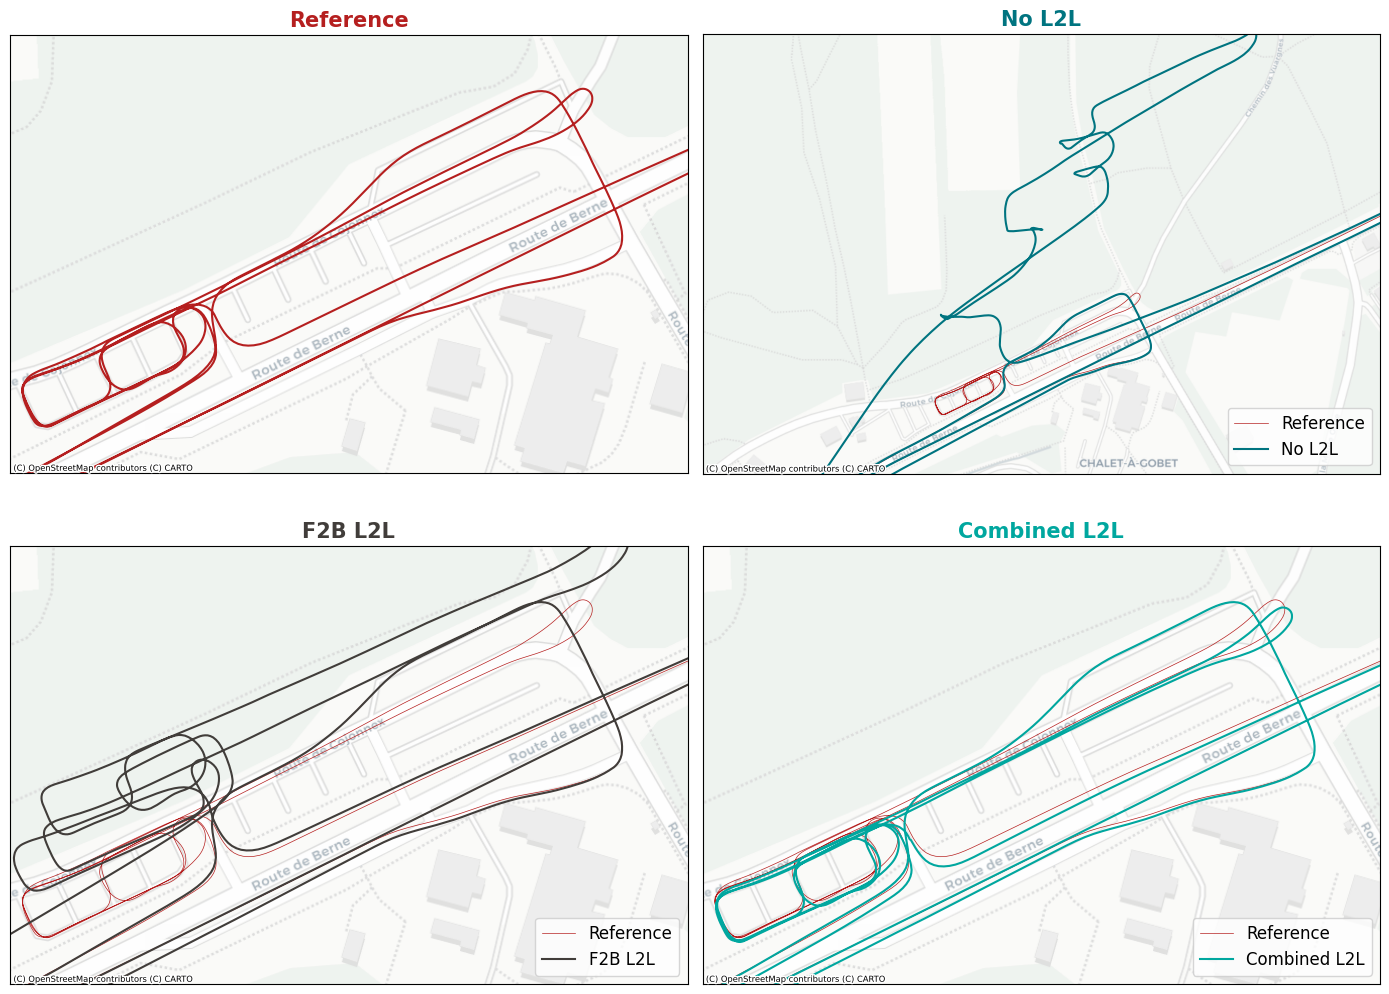

In [47]:
# ============================================================
# CELL 4 — Plot 4 quadrants
# ============================================================
COLORS = {
    label2: "#B51F1F",
    label3: "#007480",
    label4: "#413D3A",
    label5: "#00A79F",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
#fig.suptitle("Trajectory comparison — GNSS outage (parking area)", fontsize=14, y=0.99)

configs = [
    (axes[0, 0], x2, y2, label2, xmin,     xmax,     ymin,     ymax    ),
    (axes[0, 1], x3, y3, label3, xmin_out, xmax_out, ymin_out, ymax_out),
    (axes[1, 0], x4, y4, label4, xmin,     xmax,     ymin,     ymax    ),
    (axes[1, 1], x5, y5, label5, xmin,     xmax,     ymin,     ymax    ),
]

for ax, x, y, label, x0, x1, y0, y1 in configs:
    if label != label2:
        ax.plot(x2, y2, color="#B51F1F", lw=0.5, zorder=1)
    ax.plot(x, y, color=COLORS[label], lw=1.5, zorder=2)
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_title(label, fontsize=15, color=COLORS[label], fontweight="bold")
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    try:
        ctx.add_basemap(ax, crs="EPSG:3857",
                        source=ctx.providers.CartoDB.Positron,
                        zoom="auto", attribution_size=6)
    except Exception as e:
        print(f"  [WARN] basemap {label}: {e}")
    if label != label2:
        ax.legend(fontsize=12, loc="lower right", handles=[
            plt.Line2D([0],[0], color="#B51F1F", lw=0.5, label="Reference"),
            plt.Line2D([0],[0], color=COLORS[label], lw=1.5, label=label),
        ])

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("/home/b085164/PDM_Romain_Defferrard/traj_4quadrants_out2.png",
            dpi=200, bbox_inches="tight")
plt.show()

# Traj ECCR Zone 3

In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import folium

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
out2_path = Path("/media/b085164/LaCie/2026spring_RD/ECCR/ODyN/zone_3_final/AIRINS/COMBINED/out/COMBINED_AIRINS_3_ECCR.out")
out3_path = Path("/media/b085164/LaCie/2026spring_RD/ECCR/ODyN/zone_3_final/APX/outage/out/Outage_3_ECCR_APX.out")
out4_path = Path("/media/b085164/LaCie/2026spring_RD/ECCR/ODyN/zone_3_final/APX/F2B/out/F2B_3_APX.out")
out5_path = Path("/media/b085164/LaCie/2026spring_RD/ECCR/ODyN/zone_3_final/APX/COMBINED/in/v2/out_v5/combined_tmp_v5.out")
label2 = "Reference"
label3 = "No L2L"
label4 = "F2B L2L"
label5 = "Combined L2L"
t_start = None
t_end   = None
max_display_points = 5000
output_html = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_apx_outage_3_ECCR.html")

# ------------------------------------------------------------
# SBET dtype + helpers
# ------------------------------------------------------------
SBET_DTYPE = np.dtype([
    ("time",    np.float64), ("lat",  np.float64), ("lon",   np.float64),
    ("alt",     np.float64), ("vx",   np.float64), ("vy",    np.float64),
    ("vz",      np.float64), ("roll", np.float64), ("pitch", np.float64),
    ("heading", np.float64), ("wander",np.float64),("ax",    np.float64),
    ("ay",      np.float64), ("az",   np.float64), ("wx",    np.float64),
    ("wy",      np.float64), ("wz",   np.float64),
])

def load_sbet(path):
    return pd.DataFrame(np.fromfile(path, dtype=SBET_DTYPE))

def filter_time_window(df, t0, t1):
    mask = np.ones(len(df), dtype=bool)
    if t0 is not None: mask &= df["time"].to_numpy() >= t0
    if t1 is not None: mask &= df["time"].to_numpy() <= t1
    out = df.loc[mask].copy()
    if len(out) == 0:
        raise ValueError("No samples in selected time window.")
    return out

def decimate(arr, n):
    if len(arr) <= n: return arr
    return arr[np.linspace(0, len(arr)-1, n).astype(int)]

# ------------------------------------------------------------
# Load + filter
# ------------------------------------------------------------
df2 = filter_time_window(load_sbet(out2_path), t_start, t_end)
df3 = filter_time_window(load_sbet(out3_path), t_start, t_end)
df4 = filter_time_window(load_sbet(out4_path), t_start, t_end)
df5 = filter_time_window(load_sbet(out5_path), t_start, t_end)

lat2 = np.degrees(decimate(df2["lat"].to_numpy(), max_display_points))
lon2 = np.degrees(decimate(df2["lon"].to_numpy(), max_display_points))
lat3 = np.degrees(decimate(df3["lat"].to_numpy(), max_display_points))
lon3 = np.degrees(decimate(df3["lon"].to_numpy(), max_display_points))
lat4 = np.degrees(decimate(df4["lat"].to_numpy(), max_display_points))
lon4 = np.degrees(decimate(df4["lon"].to_numpy(), max_display_points))
lat5 = np.degrees(decimate(df5["lat"].to_numpy(), max_display_points))
lon5 = np.degrees(decimate(df5["lon"].to_numpy(), max_display_points))

# ------------------------------------------------------------
# Folium map
# ------------------------------------------------------------
# ------------------------------------------------------------
# Folium map
# ------------------------------------------------------------
def add_traj_with_time(m, lats, lons, times, color, label, group):
    """Ajoute une trajectoire avec tooltip temps GPS sur chaque segment."""
    n = len(lats)
    for i in range(n - 1):
        folium.PolyLine(
            locations=[(lats[i], lons[i]), (lats[i+1], lons[i+1])],
            color=color, weight=2, opacity=0.9,
            tooltip=f"{label} | t = {times[i]:.3f} s",
        ).add_to(group)

center = [lat2.mean(), lon2.mean()]
m = folium.Map(
    location=center,
    zoom_start=14,
    max_zoom=22,  # au lieu de 19
    tiles="https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
    attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/">CARTO</a>',
    name="CartoDB Positron",
)

# Décimer aussi les temps
def decimate_times(df, n):
    arr = df["time"].to_numpy()
    if len(arr) <= n: return arr
    return arr[np.linspace(0, len(arr)-1, n).astype(int)]

t2 = decimate_times(df2, max_display_points)
t3 = decimate_times(df3, max_display_points)
t4 = decimate_times(df4, max_display_points)
t5 = decimate_times(df5, max_display_points)

fg2 = folium.FeatureGroup(name=label2, show=True).add_to(m)
add_traj_with_time(m, lat2, lon2, t2, "#e74c3c", label2, fg2)

fg3 = folium.FeatureGroup(name=label3, show=True).add_to(m)
add_traj_with_time(m, lat3, lon3, t3, "#2980b9", label3, fg3)

fg4 = folium.FeatureGroup(name=label4, show=True).add_to(m)
add_traj_with_time(m, lat4, lon4, t4, "#27ae60", label4, fg4)

fg5 = folium.FeatureGroup(name=label5, show=True).add_to(m)
add_traj_with_time(m, lat5, lon5, t5, "#e67e22", label5, fg5)

# legend_html = f"""
# <div style="position:fixed;top:30px;right:30px;z-index:1000;
#             background:white;padding:8px 12px;border-radius:6px;
#             box-shadow:2px 2px 6px rgba(0,0,0,0.3);font-size:13px;">
#   <span style="color:#e74c3c;">&#9644;</span> {label2}<br>
#   <span style="color:#2980b9;">&#9644;</span> {label3}<br>
#   <span style="color:#27ae60;">&#9644;</span> {label4}<br>
#   <span style="color:#e67e22;">&#9644;</span> {label5}
# </div>
# """
legend_html = f"""
<div style="position:fixed;top:30px;right:30px;z-index:1000;
            background:white;padding:8px 12px;border-radius:6px;
            box-shadow:2px 2px 6px rgba(0,0,0,0.3);font-size:13px;">
  <span style="color:#e74c3c;">&#9644;</span> {label2}<br>
  <span style="color:#2980b9;">&#9644;</span> {label3}<br>
  <span style="color:#27ae60;">&#9644;</span> {label4}<br>
  <span style="color:#e67e22;">&#9644;</span> {label5}
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

from folium import plugins
folium.plugins.MeasureControl(position="bottomright", primary_length_unit="meters", max_width=300).add_to(m)
m.get_root().html.add_child(folium.Element("""
<script>
  document.addEventListener("DOMContentLoaded", function() {
    var maps = Object.values(window).filter(v => v && v._leaflet_id);
    if (maps.length) L.control.scale({position:"bottomright", imperial:false, maxWidth:400}).addTo(maps[0]);
  });
</script>
"""))

m.save(str(output_html))
print(f"Saved: {output_html}")

Saved: /home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_apx_outage_3_ECCR.html


In [15]:
# ============================================================
# CELL 1 — Imports supplémentaires
# ============================================================
import matplotlib.pyplot as plt
import contextily as ctx
from pyproj import Transformer

# ============================================================
# CELL 2 — Projection Mercator
# ============================================================
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

def to_mercator(lats, lons):
    x, y = transformer.transform(lons, lats)
    return np.array(x), np.array(y)

def bbox_mercator(lat_mn, lat_mx, lon_mn, lon_mx):
    x0, y0 = transformer.transform(lon_mn, lat_mn)
    x1, y1 = transformer.transform(lon_mx, lat_mx)
    return x0, x1, y0, y1

x2, y2 = to_mercator(lat2, lon2)
x3, y3 = to_mercator(lat3, lon3)
x4, y4 = to_mercator(lat4, lon4)
x5, y5 = to_mercator(lat5, lon5)

In [16]:
# Centre parking : 46°33'53.3"N 6°41'27.8"E
LAT_CENTER = 46.5439
LON_CENTER = 6.568396

# Plus serré — ajuste ces deux valeurs
MARGIN_LAT = 0.0010   # ~90m nord-sud
MARGIN_LON = 0.002   # ~130m est-ouest (parking est plus large qu'haut)

lat_min = LAT_CENTER - MARGIN_LAT
lat_max = LAT_CENTER + MARGIN_LAT
lon_min = LON_CENTER - MARGIN_LON
lon_max = LON_CENTER + MARGIN_LON

xmin, xmax, ymin, ymax = bbox_mercator(lat_min, lat_max, lon_min, lon_max)

# Outage inchangé
LAT_CENTER_OUT = 46.5441
LON_CENTER_OUT = 6.568396
MARGIN_LAT_OUT = 0.0015   # ~90m nord-sud
MARGIN_LON_OUT = 0.003   # ~130m est-ouest (parking est plus large qu'haut)

lat_min_out = LAT_CENTER_OUT - MARGIN_LAT_OUT
lat_max_out = LAT_CENTER_OUT + MARGIN_LAT_OUT
lon_min_out = LON_CENTER_OUT - MARGIN_LON_OUT
lon_max_out = LON_CENTER_OUT + MARGIN_LON_OUT

xmin_out, xmax_out, ymin_out, ymax_out = bbox_mercator(
    lat_min_out, lat_max_out, lon_min_out, lon_max_out
)

print(f"Bbox : lat=[{lat_min:.6f}, {lat_max:.6f}]  lon=[{lon_min:.6f}, {lon_max:.6f}]")

Bbox : lat=[46.542900, 46.544900]  lon=[6.566396, 6.570396]


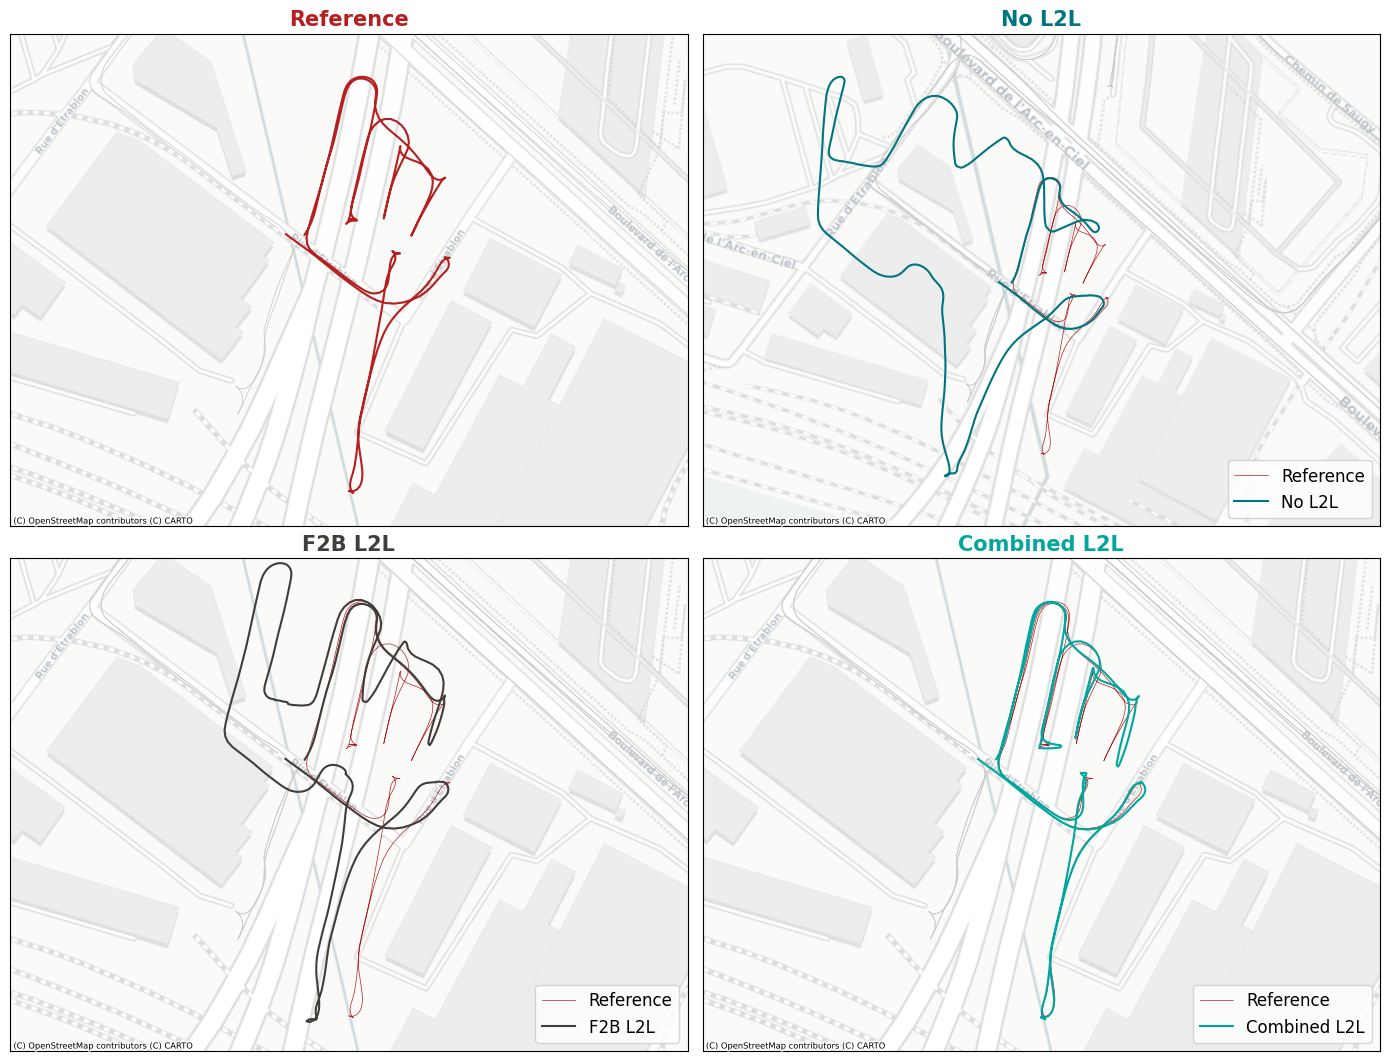

In [17]:
# ============================================================
# CELL 4 — Plot 4 quadrants
# ============================================================
COLORS = {
    label2: "#B51F1F",
    label3: "#007480",
    label4: "#413D3A",
    label5: "#00A79F",
}

T_OUT_START = 315642
T_OUT_END   = 316070

def plot_traj_with_outage(ax, x, y, t, color, lw=1.5):
    """Plot trajectory: outage window in color, rest in light gray."""
    mask_out = (t >= T_OUT_START) & (t <= T_OUT_END)
    # gray segments outside outage
    for seg_mask in [~mask_out]:
        idxs = np.where(seg_mask)[0]
        if len(idxs) == 0:
            continue
        # split into contiguous runs to avoid connecting gaps
        breaks = np.where(np.diff(idxs) > 1)[0] + 1
        runs = np.split(idxs, breaks)
        for run in runs:
            if len(run) > 1:
                ax.plot(x[run], y[run], color="#CCCCCC", lw=0.6, zorder=1)
    # colored segment inside outage
    idxs_in = np.where(mask_out)[0]
    if len(idxs_in) > 1:
        ax.plot(x[idxs_in], y[idxs_in], color=color, lw=lw, zorder=2)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

configs = [
    (axes[0, 0], x2, y2, t2, label2, xmin,     xmax,     ymin,     ymax    ),
    (axes[0, 1], x3, y3, t3, label3, xmin_out, xmax_out, ymin_out, ymax_out),
    (axes[1, 0], x4, y4, t4, label4, xmin,     xmax,     ymin,     ymax    ),
    (axes[1, 1], x5, y5, t5, label5, xmin,     xmax,     ymin,     ymax    ),
]

for ax, x, y, t, label, x0, x1, y0, y1 in configs:
    if label != label2:
        plot_traj_with_outage(ax, x2, y2, t2, "#B51F1F", lw=0.5)
    plot_traj_with_outage(ax, x, y, t, COLORS[label], lw=1.5)
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_title(label, fontsize=15, color=COLORS[label], fontweight="bold")
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    try:
        ctx.add_basemap(ax, crs="EPSG:3857",
                        source=ctx.providers.CartoDB.Positron,
                        zoom="auto", attribution_size=6)
    except Exception as e:
        print(f"  [WARN] basemap {label}: {e}")
    if label != label2:
        ax.legend(fontsize=12, loc="lower right", handles=[
            plt.Line2D([0],[0], color="#B51F1F", lw=0.5,  label="Reference"),
            plt.Line2D([0],[0], color=COLORS[label], lw=1.5, label=label),
        ])

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("/home/b085164/PDM_Romain_Defferrard/traj_4quadrants_ECCR.png",
            dpi=200, bbox_inches="tight")
plt.show()

# Erreur parking seulement

In [7]:
# ============================================================
# CELL 5 — Calcul erreurs depuis les SBET bruts
# ============================================================
from pyproj import Transformer as _T

_ecef = _T.from_crs("EPSG:4326", "EPSG:4978", always_xy=False)

def sbet_to_ecef(df):
    lat = df["lat"].to_numpy()
    lon = df["lon"].to_numpy()
    alt = df["alt"].to_numpy()
    x, y, z = _ecef.transform(np.degrees(lat), np.degrees(lon), alt)
    return np.column_stack([x, y, z])

def R_ned2e(lat, lon):
    c, s = np.cos, np.sin
    return np.array([
        [-s(lat)*c(lon), -s(lon), -c(lat)*c(lon)],
        [-s(lat)*s(lon),  c(lon), -c(lat)*s(lon)],
        [ c(lat),         0,      -s(lat)        ]
    ])

def compute_ned_error(df_ref, df_comp):
    """Interpoler df_comp sur les temps de df_ref et calculer erreur NED."""
    t_ref  = df_ref["time"].to_numpy()
    t_comp = df_comp["time"].to_numpy()

    ecef_ref  = sbet_to_ecef(df_ref)
    ecef_comp = sbet_to_ecef(df_comp)

    # Interpoler df_comp sur t_ref
    ecef_interp = np.column_stack([
        np.interp(t_ref, t_comp, ecef_comp[:, i]) for i in range(3)
    ])

    err_ecef = ecef_ref - ecef_interp

    # Convertir en NED local
    lat_ref = df_ref["lat"].to_numpy()
    lon_ref = df_ref["lon"].to_numpy()

    err_ned = np.array([
        R_ned2e(lat_ref[i], lon_ref[i]).T @ err_ecef[i]
        for i in range(len(t_ref))
    ])

    planim = np.sqrt(err_ned[:, 0]**2 + err_ned[:, 1]**2)
    altim  = err_ned[:, 2]

    return t_ref, planim, altim

print("Calcul des erreurs...")
t_ref, e3_planim, e3_altim = compute_ned_error(df2, df3)
_,     e4_planim, e4_altim = compute_ned_error(df2, df4)
_,     e5_planim, e5_altim = compute_ned_error(df2, df5)

errors_raw = {
    label3: {"t": t_ref, "planim": e3_planim, "altim": e3_altim},
    label4: {"t": t_ref, "planim": e4_planim, "altim": e4_altim},
    label5: {"t": t_ref, "planim": e5_planim, "altim": e5_altim},
}
print("OK")

Calcul des erreurs...
OK


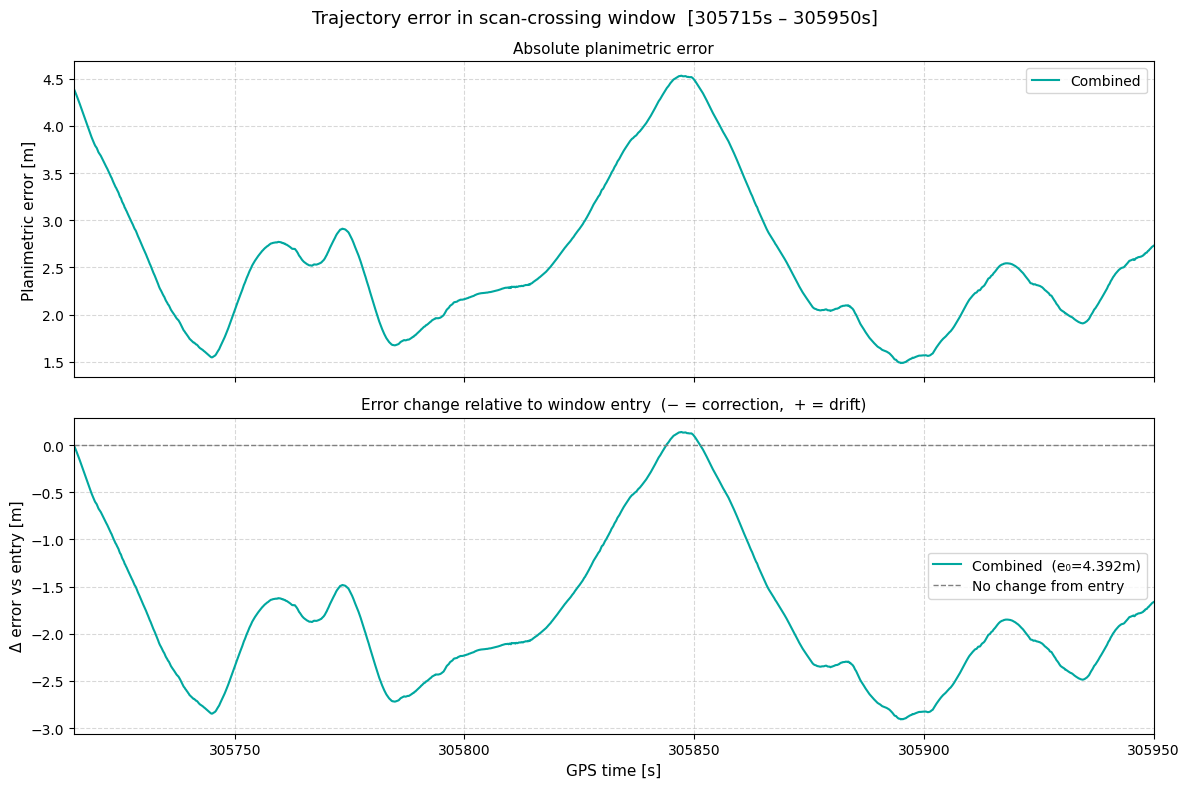


  e_entry : 4.392 m
  e_exit  : 2.728 m
  Δe      : -1.664 m
  max     : 4.532 m
  mean    : 2.566 m


In [15]:
# ============================================================
# CELL 6 — Fenêtre d'analyse croisements (ref vs combined)
# ============================================================
T_CROSS_START = 305715.0
T_CROSS_END   = 305950.0

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle(
    f"Trajectory error in scan-crossing window  [{T_CROSS_START:.0f}s – {T_CROSS_END:.0f}s]",
    fontsize=13
)

t       = errors_raw[label5]["t"]
planim  = errors_raw[label5]["planim"]
mask    = (t >= T_CROSS_START) & (t <= T_CROSS_END)
t_w     = t[mask]
e_w     = planim[mask]
e0      = e_w[0]

# AX0 — erreur absolue
axes[0].plot(t_w, e_w, color="#00A79F", lw=1.5, label=label5)
axes[0].set_ylabel("Planimetric error [m]", fontsize=11)
axes[0].set_title("Absolute planimetric error", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(color="grey", ls="--", alpha=0.3)

# AX1 — erreur relative à l'entrée
axes[1].plot(t_w, e_w - e0, color="#00A79F", lw=1.5,
             label=f"{label5}  (e₀={e0:.3f}m)")
axes[1].axhline(0, color="grey", lw=1.0, ls="--", label="No change from entry")
axes[1].set_ylabel("Δ error vs entry [m]", fontsize=11)
axes[1].set_xlabel("GPS time [s]", fontsize=11)
axes[1].set_title(
    "Error change relative to window entry  (− = correction,  + = drift)",
    fontsize=11
)
axes[1].legend(fontsize=10)
axes[1].grid(color="grey", ls="--", alpha=0.3)

for ax in axes:
    ax.set_xlim(T_CROSS_START, T_CROSS_END)

plt.tight_layout()
plt.savefig("/home/b085164/PDM_Romain_Defferrard/crossing_window_combined.png",
            dpi=200, bbox_inches="tight")
plt.show()

# Stats
print(f"\n  e_entry : {e0:.3f} m")
print(f"  e_exit  : {e_w[-1]:.3f} m")
print(f"  Δe      : {e_w[-1]-e0:+.3f} m")
print(f"  max     : {e_w.max():.3f} m")
print(f"  mean    : {e_w.mean():.3f} m")

In [10]:
# ============================================================
# CELL 7 — Stats dans la fenêtre
# ============================================================
print(f"\nFenêtre croisements [{T_CROSS_START:.0f}s – {T_CROSS_END:.0f}s]\n")
print(f"{'Trajectoire':<30} {'e_entry':>8} {'e_exit':>8} {'Δe':>8} {'max_e':>8} {'mean_e':>8}")
print("-" * 72)

for lbl, data in errors_raw.items():
    t      = data["t"]
    planim = data["planim"]
    mask   = (t >= T_CROSS_START) & (t <= T_CROSS_END)
    e_w    = planim[mask]
    e0, e1 = e_w[0], e_w[-1]
    print(f"  {lbl:<28} {e0:>8.3f} {e1:>8.3f} {e1-e0:>+8.3f} "
          f"{e_w.max():>8.3f} {e_w.mean():>8.3f}")


Fenêtre croisements [305705s – 305950s]

Trajectoire                     e_entry   e_exit       Δe    max_e   mean_e
------------------------------------------------------------------------
  ODyN outage APX                25.363  260.859 +235.496  339.016  231.488
  F2B                             4.137   39.016  +34.879   46.361   32.359
  Combined                        4.472    2.728   -1.744    4.737    2.650


# ---------------------

In [13]:
# ============================================================
# Sync check: IMU.txt vs GPS_vel_raw.txt vs reference.out (SBET)
# - loads:
#     * IMU text file
#     * GPS text file with last 3 columns = velocities
#     * binary SBET .out trajectory
# - compares:
#     * GPS speed vs trajectory speed
#     * IMU gyro Z vs heading rate from trajectory
#     * IMU-derived nav acceleration vs trajectory-derived acceleration
# - estimates best lag by cross-correlation
# - interactive Plotly figures
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ------------------------------------------------------------
# USER PATHS
# ------------------------------------------------------------
imu_path  = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/raw/raw_IMU.txt")
gps_path  = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/raw/GPS_vel_raw.txt")         # adapte si besoin
traj_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/v1/reference.out")           # adapte si besoin

In [37]:
import numpy as np

# ── Entrée ────────────────────────────────────────────────────────────────
q = [+0.999997, +0.000017, +0.001041, -0.002330]  # [w, x, y, z]
sigma_deg = [ 0.006586, 0.013934, 0.016645 ]           # 1σ r/p/y (deg)

# ── Conversion (convention extrinsic ZYX) ────────────────────────────────
w, x, y, z = q
roll  = np.arctan2(2*(w*x + y*z), 1 - 2*(x**2 + y**2))
pitch = np.arcsin( 2*(w*y - z*x))
yaw   = np.arctan2(2*(w*z + x*y), 1 - 2*(y**2 + z**2))

# ── Affichage ─────────────────────────────────────────────────────────────
for name, val_rad, sig in zip(
        ["Roll ", "Pitch", "Yaw  "],
        [roll, pitch, yaw],
        sigma_deg):
    print(f"{name}  {val_rad:+.6f} rad   {np.degrees(val_rad):+.4f}°  ±{sig:.4f}°")

Roll   +0.000029 rad   +0.0017°  ±0.0066°
Pitch  +0.002082 rad   +0.1193°  ±0.0139°
Yaw    -0.004660 rad   -0.2670°  ±0.0166°


In [39]:
from pathlib import Path
import copy
import numpy as np
import laspy
from tqdm import tqdm
from matplotlib.path import Path as MplPath
from typing import Union
# ============================================================
# Inputs
# ============================================================

las_1 = Path("/media/b085164/Elements/CALIB_26_02_25/georef_puck/puck_new_leverarm/PUCK/lidar_20260225_124315_pcd.las")
las_2 = Path("/media/b085164/Elements/CALIB_26_02_25/georef_puck/puck_new_leverarm/PUCK/lidar_20260225_125030_pcd.las")

out_1 = las_1.with_name(las_1.stem + "_zone_clip.las")
out_2 = las_2.with_name(las_2.stem + "_zone_clip_first_pass.las")

# ============================================================
# Polygon coordinates from your screenshots (Xg, Yg)
# ============================================================

poly_xy = np.array([
    [2542392.407013, 1157065.625977],  # point 1
    [2542354.688995, 1157096.387024],  # point 2
    [2542337.899994, 1157075.195007],  # point 3
    [2542375.092987, 1157043.383972],  # point 4
], dtype=np.float64)

# Sort vertices around centroid to ensure a valid polygon order
centroid = poly_xy.mean(axis=0)
angles = np.arctan2(poly_xy[:, 1] - centroid[1], poly_xy[:, 0] - centroid[0])
poly_xy = poly_xy[np.argsort(angles)]

poly_path = MplPath(poly_xy)

print("Polygon vertices used:")
for i, (x, y) in enumerate(poly_xy, start=1):
    print(f"  {i}: X={x:.6f}, Y={y:.6f}")

# ============================================================
# Helpers
# ============================================================

def polygon_mask(points_xy: np.ndarray, poly_path: MplPath) -> np.ndarray:
    # Small positive radius to include boundary points more safely
    return poly_path.contains_points(points_xy, radius=1e-9)

def clip_las_with_polygon(
    in_path: Path,
    out_path: Path,
    poly_path: MplPath,
    chunk_size: int = 2_000_000,
    time_window: Union[tuple[float, float],None] = None,
) -> int:
    """
    Clip LAS by XY polygon.
    If time_window=(t0,t1) is given, also filter by gps_time.
    Returns number of kept points.
    """
    kept_total = 0
    out_path.parent.mkdir(parents=True, exist_ok=True)

    with laspy.open(in_path) as reader:
        header = copy.deepcopy(reader.header)

        with laspy.open(out_path, mode="w", header=header) as writer:
            with tqdm(total=reader.header.point_count, desc=f"Clip {in_path.name}", unit="pts") as pbar:
                for points in reader.chunk_iterator(chunk_size):
                    pbar.update(len(points))

                    xy = np.column_stack((points.x, points.y))
                    mask = polygon_mask(xy, poly_path)

                    if time_window is not None:
                        t0, t1 = time_window
                        gps_t = np.asarray(points.gps_time, dtype=np.float64)
                        mask &= (gps_t >= t0) & (gps_t <= t1)

                    n = int(mask.sum())
                    if n > 0:
                        writer.write_points(points[mask])
                        kept_total += n

    print(f"[done] {in_path.name} -> {out_path.name} | kept {kept_total:,} points")
    return kept_total

def collect_times_in_polygon(
    in_path: Path,
    poly_path: MplPath,
    chunk_size: int = 2_000_000,
) -> np.ndarray:
    """
    Collect gps_time only for points inside the polygon.
    Used to detect the first passage in the zone.
    """
    times = []

    with laspy.open(in_path) as reader:
        with tqdm(total=reader.header.point_count, desc=f"Collect times {in_path.name}", unit="pts") as pbar:
            for points in reader.chunk_iterator(chunk_size):
                pbar.update(len(points))

                xy = np.column_stack((points.x, points.y))
                mask = polygon_mask(xy, poly_path)

                if np.any(mask):
                    t = np.asarray(points.gps_time[mask], dtype=np.float64)
                    if t.size > 0:
                        times.append(t)

    if not times:
        raise RuntimeError(f"No points found inside polygon for {in_path}")

    return np.concatenate(times)

def infer_first_passage_window(
    times: np.ndarray,
    gap_thresh_s: Union[float,None] = None,
) -> tuple[float, float]:
    """
    Detect the first temporal cluster inside the polygon.
    If there are multiple passages separated by a large time gap,
    keep only the first one.
    """
    times = np.asarray(times, dtype=np.float64)
    times = np.sort(times)

    if times.size == 0:
        raise RuntimeError("Empty time array.")

    dt = np.diff(times)
    pos_dt = dt[dt > 0]

    if gap_thresh_s is None:
        if pos_dt.size == 0:
            gap_thresh_s = 0.5
        else:
            med_dt = float(np.median(pos_dt))
            gap_thresh_s = max(0.5, 50.0 * med_dt)

    gap_idx = np.where(dt > gap_thresh_s)[0]

    if gap_idx.size == 0:
        t0 = float(times[0])
        t1 = float(times[-1])
        print(f"[first passage] only one time cluster detected | window=[{t0:.6f}, {t1:.6f}] | gap_thresh={gap_thresh_s:.6f}s")
        return t0, t1

    first_gap = int(gap_idx[0])
    t0 = float(times[0])
    t1 = float(times[first_gap])

    print(f"[first passage] window=[{t0:.6f}, {t1:.6f}] | first large gap after {t1:.6f} | gap_thresh={gap_thresh_s:.6f}s")
    return t0, t1

# ============================================================
# Run
# ============================================================

# 1) First cloud: keep everything inside polygon
clip_las_with_polygon(
    in_path=las_1,
    out_path=out_1,
    poly_path=poly_path,
)

# 2) Second cloud: detect first passage only
times_2 = collect_times_in_polygon(
    in_path=las_2,
    poly_path=poly_path,
)

t0_2, t1_2 = infer_first_passage_window(times_2)

clip_las_with_polygon(
    in_path=las_2,
    out_path=out_2,
    poly_path=poly_path,
    time_window=(t0_2, t1_2),
)

print("\nOutputs:")
print(out_1)
print(out_2)

Polygon vertices used:
  1: X=2542375.092987, Y=1157043.383972
  2: X=2542392.407013, Y=1157065.625977
  3: X=2542354.688995, Y=1157096.387024
  4: X=2542337.899994, Y=1157075.195007


Clip lidar_20260225_124315_pcd.las: 100%|██████████| 45459189/45459189 [00:16<00:00, 2819234.41pts/s]


[done] lidar_20260225_124315_pcd.las -> lidar_20260225_124315_pcd_zone_clip.las | kept 244,770 points


Collect times lidar_20260225_125030_pcd.las: 100%|██████████| 161935392/161935392 [00:58<00:00, 2790070.04pts/s]


[first passage] window=[305981.531044, 305986.594932] | first large gap after 305986.594932 | gap_thresh=0.500000s


Clip lidar_20260225_125030_pcd.las: 100%|██████████| 161935392/161935392 [00:05<00:00, 28289355.39pts/s]

[done] lidar_20260225_125030_pcd.las -> lidar_20260225_125030_pcd_zone_clip_first_pass.las | kept 199,973 points

Outputs:
/media/b085164/Elements/CALIB_26_02_25/georef_puck/puck_new_leverarm/PUCK/lidar_20260225_124315_pcd_zone_clip.las
/media/b085164/Elements/CALIB_26_02_25/georef_puck/puck_new_leverarm/PUCK/lidar_20260225_125030_pcd_zone_clip_first_pass.las


In [52]:
from pathlib import Path
import numpy as np
import pandas as pd
import folium

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
out2_path = Path("/media/b085164/LaCie/2026spring_RD/ECCR/ODyN/ALS-MLS/base/out/ECCR_ALS-MLS_base.out")
out3_path = Path("/media/b085164/LaCie/2026spring_RD/ECCR/ODyN/ALS-MLS/outage/out/ECCR_ALS-MLS_outage.out")

label2 = "Reference"
label3 = "No L2L"

t_start = None
t_end   = None
max_display_points = 5000
output_html = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_ECCR_ALS-MLS.html")

# ------------------------------------------------------------
# SBET dtype + helpers
# ------------------------------------------------------------
SBET_DTYPE = np.dtype([
    ("time",    np.float64), ("lat",  np.float64), ("lon",   np.float64),
    ("alt",     np.float64), ("vx",   np.float64), ("vy",    np.float64),
    ("vz",      np.float64), ("roll", np.float64), ("pitch", np.float64),
    ("heading", np.float64), ("wander",np.float64),("ax",    np.float64),
    ("ay",      np.float64), ("az",   np.float64), ("wx",    np.float64),
    ("wy",      np.float64), ("wz",   np.float64),
])

def load_sbet(path):
    return pd.DataFrame(np.fromfile(path, dtype=SBET_DTYPE))

def filter_time_window(df, t0, t1):
    mask = np.ones(len(df), dtype=bool)
    if t0 is not None: mask &= df["time"].to_numpy() >= t0
    if t1 is not None: mask &= df["time"].to_numpy() <= t1
    out = df.loc[mask].copy()
    if len(out) == 0:
        raise ValueError("No samples in selected time window.")
    return out

def decimate(arr, n):
    if len(arr) <= n: return arr
    return arr[np.linspace(0, len(arr)-1, n).astype(int)]

# ------------------------------------------------------------
# Load + filter
# ------------------------------------------------------------
df2 = filter_time_window(load_sbet(out2_path), t_start, t_end)
df3 = filter_time_window(load_sbet(out3_path), t_start, t_end)


lat2 = np.degrees(decimate(df2["lat"].to_numpy(), max_display_points))
lon2 = np.degrees(decimate(df2["lon"].to_numpy(), max_display_points))
lat3 = np.degrees(decimate(df3["lat"].to_numpy(), max_display_points))
lon3 = np.degrees(decimate(df3["lon"].to_numpy(), max_display_points))


# ------------------------------------------------------------
# Folium map
# ------------------------------------------------------------
# ------------------------------------------------------------
# Folium map
# ------------------------------------------------------------
def add_traj_with_time(m, lats, lons, times, color, label, group):
    """Ajoute une trajectoire avec tooltip temps GPS sur chaque segment."""
    n = len(lats)
    for i in range(n - 1):
        folium.PolyLine(
            locations=[(lats[i], lons[i]), (lats[i+1], lons[i+1])],
            color=color, weight=2, opacity=0.9,
            tooltip=f"{label} | t = {times[i]:.3f} s",
        ).add_to(group)

center = [lat2.mean(), lon2.mean()]
m = folium.Map(
    location=center,
    zoom_start=14,
    max_zoom=22,  # au lieu de 19
    tiles="https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
    attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/">CARTO</a>',
    name="CartoDB Positron",
)

# Décimer aussi les temps
def decimate_times(df, n):
    arr = df["time"].to_numpy()
    if len(arr) <= n: return arr
    return arr[np.linspace(0, len(arr)-1, n).astype(int)]

t2 = decimate_times(df2, max_display_points)
t3 = decimate_times(df3, max_display_points)

fg2 = folium.FeatureGroup(name=label2, show=True).add_to(m)
add_traj_with_time(m, lat2, lon2, t2, "#e74c3c", label2, fg2)

fg3 = folium.FeatureGroup(name=label3, show=True).add_to(m)
add_traj_with_time(m, lat3, lon3, t3, "#2980b9", label3, fg3)


# legend_html = f"""
# <div style="position:fixed;top:30px;right:30px;z-index:1000;
#             background:white;padding:8px 12px;border-radius:6px;
#             box-shadow:2px 2px 6px rgba(0,0,0,0.3);font-size:13px;">
#   <span style="color:#e74c3c;">&#9644;</span> {label2}<br>
#   <span style="color:#2980b9;">&#9644;</span> {label3}<br>
#   <span style="color:#27ae60;">&#9644;</span> {label4}<br>
#   <span style="color:#e67e22;">&#9644;</span> {label5}
# </div>
# """
legend_html = f"""
<div style="position:fixed;top:30px;right:30px;z-index:1000;
            background:white;padding:8px 12px;border-radius:6px;
            box-shadow:2px 2px 6px rgba(0,0,0,0.3);font-size:13px;">
  <span style="color:#e74c3c;">&#9644;</span> {label2}<br>
  <span style="color:#2980b9;">&#9644;</span> {label3}
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

from folium import plugins
folium.plugins.MeasureControl(position="bottomright", primary_length_unit="meters", max_width=300).add_to(m)
m.get_root().html.add_child(folium.Element("""
<script>
  document.addEventListener("DOMContentLoaded", function() {
    var maps = Object.values(window).filter(v => v && v._leaflet_id);
    if (maps.length) L.control.scale({position:"bottomright", imperial:false, maxWidth:400}).addTo(maps[0]);
  });
</script>
"""))

m.save(str(output_html))
print(f"Saved: {output_html}")

Saved: /home/b085164/PDM_Romain_Defferrard/ESO-PDM/traj_comparison_ECCR_ALS-MLS.html
